# Notebook de réplication d’un autocall par vanilles

## Objectif

L’idée de ce notebook est de construire une base propre pour étudier la réplication statique d’un autocall par un panier fini de vanilles.

On veut ici :

- définir clairement le produit cible ;
- poser un modèle de pricing de référence ;
- construire un univers de vanilles ;
- tester un benchmark naïf ;
- rendre le tout plus lisible et plus simple à déboguer.


In [42]:
from __future__ import annotations

from typing import Any, Dict, Optional
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from IPython.display import display


import yfinance as yf

In [43]:
np.set_printoptions(linewidth=10000)

## 2. Principe général

On part d’un autocall simple, puis on cherche à l’approximer par une combinaison linéaire de 100 à 200 vanilles observables sur le marché.

La logique du notebook est la suivante :

1. construire le payoff cible de l’autocall ;
2. construire un univers de vanilles ;
3. price les deux dans un même cadre ;
4. résoudre un problème de fit direct ;
5. mesurer la qualité de l’approximation ;
6. identifier les limites de cette baseline.

Cette baseline servira de point de comparaison pour une méthode plus intelligente fondée sur la structure du produit.

---

## 3. Produit cible

On commence par un autocall simple, à une seule sous-jacente, avec :

- plusieurs dates de constatation ;
- un coupon fixe ;
- un niveau d’autocall ;
- une barrière down éventuelle ;
- un payoff terminal simple en cas de non-rappel.

Il est important de ne pas introduire trop de complexité dès le départ.  
Le produit doit être assez riche pour être représentatif, mais assez simple pour être codé, testé et debuggué rapidement.

In [44]:
import importlib
import products_core
importlib.reload(products_core)

from products_core import AutocallProduct, VanillaProduct, EuropeanCall, EuropeanPut, BinaryCall, BinaryPut, build_vanilla_universe, vanilla_universe_to_dataframe

## Tests de cohérence du payoff de l’autocall

On construit ici trois trajectoires de prix artificielles pour vérifier que la fonction `compute_autocall_payoff` réagit correctement dans les trois situations clés :

- **Cas 1** : le produit est appelé au premier coupon.
- **Cas 2** : le produit n’est jamais appelé et la barrière n’est jamais touchée.
- **Cas 3** : le produit n’est pas appelé, mais la barrière est touchée pendant la vie du produit.

In [45]:
dates = pd.bdate_range("2025-01-01", periods=280)    # 1 an de jours ouvrés
prices = pd.Series(100.0, index=dates)

# Cas 1 : autocall au premier coupon
prices1 = prices.copy()
prices1.loc[dates[63:]] = 101.0  # autour du 3e mois

# Cas 2 : jamais appelé, pas de barrière
prices2 = prices.copy()             # spot initial constant à 99% du nominal
prices2.loc[:] = 99.0

# Cas 3 : barrière touchée = 70
prices3 = prices.copy()
prices3.loc[dates[50:80]] = 55.0
prices3.loc[dates[80:]] = 99.0

prod = AutocallProduct()

res1 = prod.compute_autocall_payoff(prices1, start_date=dates[0])
res2 = prod.compute_autocall_payoff(prices2, start_date=dates[0])
res3 = prod.compute_autocall_payoff(prices3, start_date=dates[0])

print("Called : ", res1["called"], "/ Call Date : ", res1["call_date"], "/ Undiscounted Payoff : ", res1["undiscounted_payoff"])
print("Called : ", res2["called"], "/ Call Date : ", res2["call_date"], "/ Barrier Hit : ", res2["barrier_hit"], "/ Undiscounted Payoff : ", res2["undiscounted_payoff"])
print("Called : ", res3["called"], "/ Call Date : ", res3["call_date"], "/ Barrier Hit : ", res3["barrier_hit"], "/ Undiscounted Payoff : ", res3["undiscounted_payoff"])

Called :  True / Call Date :  2025-04-01 00:00:00 / Undiscounted Payoff :  105.0
Called :  False / Call Date :  None / Barrier Hit :  False / Undiscounted Payoff :  120.0
Called :  False / Call Date :  None / Barrier Hit :  True / Undiscounted Payoff :  114.0


## 4. Univers de vanilles

On construit ensuite une base de vanilles couvrant :

- plusieurs maturités ;
- plusieurs strikes autour du spot ;
- des calls et des puts ;
- idéalement des instruments proches des dates de call de l’autocall.

L’idée est de disposer d’un dictionnaire d’instruments suffisamment riche pour que le fit direct ait une chance raisonnable de fonctionner.

Le point critique ici est la diversité du panier.  
Un panier trop concentré autour de l’ATM donne un fit fragile ; un panier trop large peut devenir instable numériquement sans régularisation.

---

## 5. Modèle de pricing de référence

Pour la première version du notebook, on choisit un cadre de pricing simple et contrôlé.

Le plus naturel est de commencer avec :

- Black-Scholes comme modèle de base ;
- éventuellement une surface implicite en second temps ;
- puis plus tard un modèle plus riche si nécessaire.

Le but est de séparer clairement :

- l’erreur liée à la réplication ;
- l’erreur liée au modèle de prix ;
- l’erreur liée à la discrétisation.

Tant que ces trois sources d’erreur ne sont pas séparées, les résultats seront difficiles à interpréter.

In [46]:
from products_core import norm_cdf, norm_pdf, bs_d1_d2, _year_fraction

## Test des produits européens et des parités Black-Scholes

On fixe ici un jeu de paramètres simple afin de tester les produits de base :

- un call européen,
- un put européen,
- un call binaire,
- un put binaire.

L’objectif est de vérifier que :
- les prix Black-Scholes sont cohérents,
- la parité put-call est bien respectée,
- la parité entre les deux options binaires est bien vérifiée,
- les payoffs terminaux correspondent aux définitions théoriques.

In [47]:
# ------------------------------------------------------------
# Paramètres de test
# ------------------------------------------------------------
valuation_date = pd.Timestamp("2026-06-20")
maturity = pd.Timestamp("2027-06-20")

spot = 100.0
strike = 100.0
rate = 0.03
dividend_yield = 0.01
vol = 0.20              
# On suppose que la volatilité est constante pour simplifier l'exemple, et unique pour toutes les options. 
# Dans la réalité, on utiliserait une surface de volatilité.

# ------------------------------------------------------------
# Création des produits
# ------------------------------------------------------------
call = EuropeanCall(name="Call_100",        strike=strike,maturity_date=maturity,notional=1.0)
put = EuropeanPut(  name="Put_100",         strike=strike,maturity_date=maturity,notional=1.0)
bcall = BinaryCall( name="BinaryCall_100",  strike=strike,maturity_date=maturity,notional=1.0)
bput = BinaryPut(   name="BinaryPut_100",   strike=strike,maturity_date=maturity,notional=1.0)

# ------------------------------------------------------------
# Prix Black-Scholes
# ------------------------------------------------------------
c = call.   price_bs(spot, valuation_date, rate, dividend_yield, vol)
p = put.    price_bs(spot, valuation_date, rate, dividend_yield, vol)
bc = bcall. price_bs(spot, valuation_date, rate, dividend_yield, vol)
bp = bput.  price_bs(spot, valuation_date, rate, dividend_yield, vol)

print("Call      :", c)
print("Put       :", p)
print("Binary call:", bc)
print("Binary put :", bp)

# ------------------------------------------------------------
# Tests de cohérence
# ------------------------------------------------------------
T = _year_fraction(valuation_date, maturity)

# Parité put-call : C - P = S0 * exp(-q*T) - K * exp(-r*T)
# Parité binaire : BC + BP = exp(-r*T)
lhs = c - p
rhs = spot * math.exp(-dividend_yield * T) - strike * math.exp(-rate * T)

print("\nPut-call parity: C - P = S0 * exp(-q*T) - K * exp(-r*T)")
print("LHS =", lhs)
print("RHS =", rhs)
print("Erreur absolue =", abs(lhs - rhs))

print("\nBinary parity: BC + BP = e^{-rT}")
print("BC + BP =", bc + bp)
print("e^{-rT}  =", math.exp(-rate * T))
print("Erreur absolue =", abs((bc + bp) - math.exp(-rate * T)))

# ------------------------------------------------------------
# Payoff terminal simple
# ------------------------------------------------------------
spot_T = 112.0
print("\nPayoffs à S_T = 112:")
print("Call payoff :", call.payoff(spot_T))
print("Put payoff  :", put.payoff(spot_T))
print("BC payoff   :", bcall.payoff(spot_T))
print("BP payoff   :", bput.payoff(spot_T))

Call      : 8.827321225352122
Put       : 6.866891205286137
Binary call: 0.4852227667742541
Binary put : 0.4852227667742541

Put-call parity: C - P = S0 * exp(-q*T) - K * exp(-r*T)
LHS = 1.960430020065985
RHS = 1.960430020065985
Erreur absolue = 0.0

Binary parity: BC + BP = e^{-rT}
BC + BP = 0.9704455335485082
e^{-rT}  = 0.9704455335485082
Erreur absolue = 0.0

Payoffs à S_T = 112:
Call payoff : 12.0
Put payoff  : 0.0
BC payoff   : 1.0
BP payoff   : 0.0


## Simulation Black-Scholes d'une trajectoire de prix

Cette fonction génère une trajectoire quotidienne du sous-jacent sous le modèle Black-Scholes.  
Elle servira ensuite à simuler des scénarios de marché pour le pricing Monte Carlo de l'autocall.

In [48]:
import monte_carlo
importlib.reload(monte_carlo)

from monte_carlo import simulate_gbm_path

## Pricing Monte Carlo de l'autocall

On simule un grand nombre de trajectoires du sous-jacent, puis on calcule le payoff de l'autocall sur chaque trajectoire.  
Le prix final est obtenu en moyennant les cashflows actualisés.

In [49]:
from monte_carlo import price_autocall_bs_mc

## Construction de la grille de travail

On construit ici deux axes de calcul :
- une liste de dates pertinentes,
- une grille de spots autour du spot initial.

Cette grille sert à étudier la valeur de l'autocall en fonction du temps et du niveau du sous-jacent.

In [50]:
import benchmark_general
importlib.reload(benchmark_general)
from benchmark_general import build_autocall_training_grid_axes, build_naive_vanilla_basis

## Surface de prix sur la grille

On calcule le prix de l'autocall pour chaque couple (date, spot) de la grille afin d'obtenir une matrice de prix.

In [51]:
import target_price
importlib.reload(target_price)

from target_price import price_autocall_on_tensor_bs_mc

## Prix de l'autocall sur une grille de dates et de spots

On instancie ici un autocall simple, puis on calcule :

1. un prix Monte Carlo sur un scénario de référence ;
2. une matrice de prix sur une grille de travail composée :
   - de plusieurs dates pertinentes,
   - de plusieurs niveaux de spot autour de `spot0`.

Le tableau affiché représente donc une surface de prix de l'autocall :
- les **lignes** correspondent aux dates,
- les **colonnes** correspondent aux spots,
- chaque case contient le prix estimé du produit pour ce couple (date, spot).

Cela permet de visualiser comment la valeur de l'autocall varie à la fois avec le temps et avec le niveau du sous-jacent.

In [52]:
prod = AutocallProduct(notional=100.0,autocall_strike=1.00,coupon_rate=0.02,down_barrier=0.70,observation_months=[3, 6, 9, 12],)

valuation_date = pd.Timestamp("2026-06-20")
maturity_date = pd.Timestamp("2027-06-20")
spot0 = 100.0
rate = 0.03
dividend_yield = 0.01
vol = 0.20

res = price_autocall_bs_mc(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,n_paths=2000)
print(res["actualized_price"], res["std_error"])

99.08412193765336 0.22082624538496165


In [53]:
dates, spots = build_autocall_training_grid_axes(spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,n_spots=15,spot_min_mult=0.6,spot_max_mult=1.4,include_call_dates=True,product=prod)

price_tensor = price_autocall_on_tensor_bs_mc(product=prod,dates=dates,spots=spots,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,n_paths=200,seed=42)

df_view = pd.DataFrame(price_tensor, index=[d.strftime("%Y-%m-%d") for d in dates], columns=np.round(spots, 2))          # tableau des prix simulés de l'autocall sur la grille (dates en lignes, spots en colonnes)       
display(df_view)
print("Prix de l'autocall : lignes = dates, colonnes = spots")


#Les 4 lignes viennent des dates d’observation : typiquement 3, 6, 9, 12 mois si observation_months = [3, 6, 9, 12].
#Les 15 colonnes viennent de n_spots=15, donc tu as pris 15 valeurs de spot entre 0.6 * spot0 et 1.4 * spot0.
#La dernière ligne entièrement à 100 suggère qu’à cette date, le payoff est identique quel que soit le spot dans ta grille, ce qui est cohérent avec un produit arrivé à une situation où le remboursement est fixé par le contrat.

,60.00,65.71,71.43,77.14,82.86,88.57,94.29,100.00,105.71,111.43,117.14,122.86,128.57,134.29,140.00
2026-09-20,99.553877,99.553877,99.563729,99.563729,99.569797,99.575864,99.581931,99.581931,99.588126,99.449804,99.437542,99.437542,99.437542,99.420041,99.426236
2026-12-20,100.300584,100.304323,100.298210,100.298210,100.298210,100.298210,100.292097,100.298210,100.294471,100.294471,100.294471,100.288359,100.294471,100.294471,100.300584
2027-03-20,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847,101.201847
2027-06-20,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


Prix de l'autocall : lignes = dates, colonnes = spots


## 6. Formulation du benchmark naïf : réplication par un portefeuille de vanilles

Le benchmark consiste à approximer la valeur de l’autocall par une combinaison linéaire de vanilles :

$$
V_{\text{autocall}}(d,s) \approx \sum_{i=1}^N w_i V_i(d,s)
$$

où :

- $V_{\text{autocall}}$ est la valeur du produit cible ;
- $V_i$ est la valeur de la vanille $i$ ;
- $w_i$ est le poids associé.
- d = une date de valorisation
- s = un niveau de spot 

Ce benchmark doit être traité comme une approximation statique simple, pas comme une réplication exacte.
L'idée est volontairement naïve :
- on construit une base de produits simples (calls / puts, éventuellement en grande quantité),
- on ajuste leurs poids pour reproduire au mieux la surface de prix de l'autocall,
- on compare ensuite la qualité de la réplication obtenue.

Ce benchmark sert de point de comparaison simple avant d'aller vers des méthodes plus sophistiquées de calibration ou d'approximation.

## Benchmark naïf par étapes

On construit ici une réplication simple de l'autocall à l'aide d'options vanilles européennes, en procédant par niveaux de complexité.

La démarche est la suivante :
1. commencer avec un portefeuille composé uniquement de calls ;
2. enrichir ensuite la base avec des calls et des puts ;
3. ajouter enfin les options binaires pour vérifier si elles améliorent sensiblement la qualité de réplication.

L’objectif est de comparer, étape par étape, la capacité de chaque famille de produits à reproduire la surface de prix de l’autocall.

In [54]:
# ============================================================
# 6. BENCHMARK NAÏF :     Calls -> Calls/Puts -> Calls/Puts/Binaires
# ============================================================

# ------------------------------------------------------------
# Pricing d'un panier sur une grille (dates x spots)
# ------------------------------------------------------------
from target_price import price_vanilla_basis_on_grid

In [55]:
# ------------------------------------------------------------
# 3) Fit ridge simple (benchmark naïf)
# ------------------------------------------------------------
from benchmark_general import fit_linear, fit_lstsq


# ------------------------------------------------------------
# 4) Métriques
# ------------------------------------------------------------
from benchmark_general import benchmark_metrics

In [56]:
# ------------------------------------------------------------
# 5) Pipeline complet
# ------------------------------------------------------------
from target_price import run_naive_benchmark_price

# ------------------------------------------------------------
# 6) Affichage / comparaison
# ------------------------------------------------------------
from benchmark_general import plot_benchmark_surface

In [57]:
# ============================================================
# EXEMPLES D'UTILISATION
# ============================================================
res_calls =         run_naive_benchmark_price(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls",n_spots=15,n_paths=200, penalty="l2")
res_calls_puts =    run_naive_benchmark_price(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls_puts",n_spots=15,n_paths=200, penalty="l2")
res_full =          run_naive_benchmark_price(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="full",n_spots=15,n_paths=200, penalty="l2")

print("=== CALLS ===")
print("Train:", res_calls["metrics_train"])
print("Test :", res_calls["metrics_test"])
display(res_calls["weights"].head(10))

print("=== CALLS + PUTS ===")
print("Train:", res_calls_puts["metrics_train"])
print("Test :", res_calls_puts["metrics_test"])
display(res_calls_puts["weights"].head(10))

print("=== FULL ===")
print("Train:", res_full["metrics_train"])
print("Test :", res_full["metrics_test"])
display(res_full["weights"].head(10))

=== CALLS ===
Train: {'mae': 0.0009433854890687598, 'rmse': 0.00204185411236561, 'max_abs_error': 0.006627770036644165, 'mean_error': -2.2263672387149805e-13}
Test : {'mae': 95.02004715688554, 'rmse': 136.46363786636036, 'max_abs_error': 390.61923343272366, 'mean_error': 38.62836502135351}


,name,kind,maturity_date,strike,weight
0,CASH_20260920,Cash,2026-09-20,0.0,63.371833
55,C_20270620_130.00,EuropeanCall,2027-06-20,130.0,-22.624716
41,C_20270320_130.00,EuropeanCall,2027-03-20,130.0,-18.282999
35,C_20270320_100.00,EuropeanCall,2027-03-20,100.0,17.109753
54,C_20270620_125.00,EuropeanCall,2027-06-20,125.0,-15.262475
27,C_20261220_130.00,EuropeanCall,2026-12-20,130.0,14.769344
43,C_20270620_70.00,EuropeanCall,2027-06-20,70.0,9.211580
36,C_20270320_105.00,EuropeanCall,2027-03-20,105.0,9.080644
30,C_20270320_75.00,EuropeanCall,2027-03-20,75.0,-8.884225
53,C_20270620_120.00,EuropeanCall,2027-06-20,120.0,-8.687399


=== CALLS + PUTS ===
Train: {'mae': 0.0007443654823840499, 'rmse': 0.0017419221634576779, 'max_abs_error': 0.00569407123130361, 'mean_error': 7.152796873318342e-14}
Test : {'mae': 179.6871656762477, 'rmse': 240.74574645181198, 'max_abs_error': 662.9564206835566, 'mean_error': 36.48737142239897}


,name,kind,maturity_date,strike,weight
0,CASH_20260920,Cash,2026-09-20,0.0,868.742967
106,C_20270620_130.00,EuropeanCall,2027-06-20,130.0,-19.960399
107,P_20270620_130.00,EuropeanPut,2027-06-20,130.0,-19.566251
79,C_20270320_130.00,EuropeanCall,2027-03-20,130.0,-17.259138
80,P_20270320_130.00,EuropeanPut,2027-03-20,130.0,-16.847117
104,C_20270620_125.00,EuropeanCall,2027-06-20,125.0,-13.629777
53,P_20261220_130.00,EuropeanPut,2026-12-20,130.0,13.374194
105,P_20270620_125.00,EuropeanPut,2027-06-20,125.0,-13.266335
68,P_20270320_100.00,EuropeanPut,2027-03-20,100.0,13.063103
67,C_20270320_100.00,EuropeanCall,2027-03-20,100.0,13.041094


=== FULL ===
Train: {'mae': 1.209798483614577e-10, 'rmse': 1.6368777947924872e-10, 'max_abs_error': 4.966835831510252e-10, 'mean_error': 9.473903143468002e-16}
Test : {'mae': 0.7262554081708685, 'rmse': 0.7962470772735137, 'max_abs_error': 1.1112061196498644, 'mean_error': 0.316679576698624}


,name,kind,maturity_date,strike,weight
0,CASH_20260920,Cash,2026-09-20,0.0,100.564483
5,C_20260920_75.00,EuropeanCall,2026-09-20,75.0,0.084946
55,P_20261220_70.00,EuropeanPut,2026-12-20,70.0,-0.078094
9,C_20260920_80.00,EuropeanCall,2026-09-20,80.0,0.076819
13,C_20260920_85.00,EuropeanCall,2026-09-20,85.0,0.068334
54,C_20261220_70.00,EuropeanCall,2026-12-20,70.0,-0.065855
33,C_20260920_110.00,EuropeanCall,2026-09-20,110.0,0.063876
17,C_20260920_90.00,EuropeanCall,2026-09-20,90.0,0.059338
21,C_20260920_95.00,EuropeanCall,2026-09-20,95.0,0.052959
25,C_20260920_100.00,EuropeanCall,2026-09-20,100.0,0.045959


,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls,9.433855e-04,2.041854e-03,6.627770e-03,-2.226367e-13,95.020047,136.463638,390.619233,38.628365
1,calls_puts,7.443655e-04,1.741922e-03,5.694071e-03,7.152797e-14,179.687166,240.745746,662.956421,36.487371
2,full,1.209798e-10,1.636878e-10,4.966836e-10,9.473903e-16,0.726255,0.796247,1.111206,0.316680


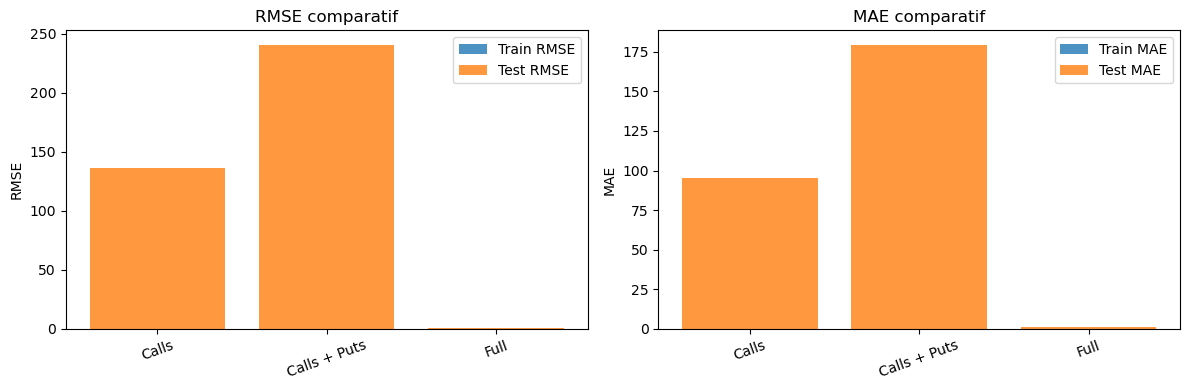

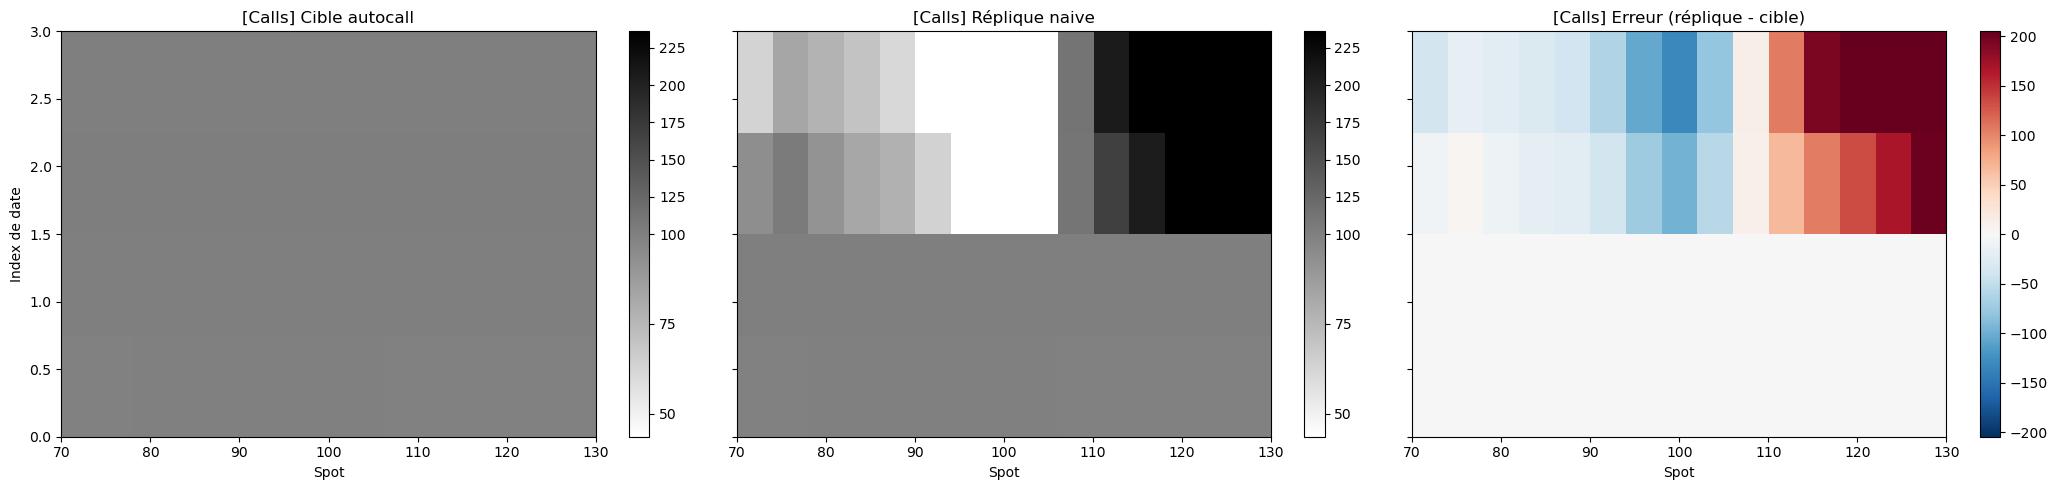

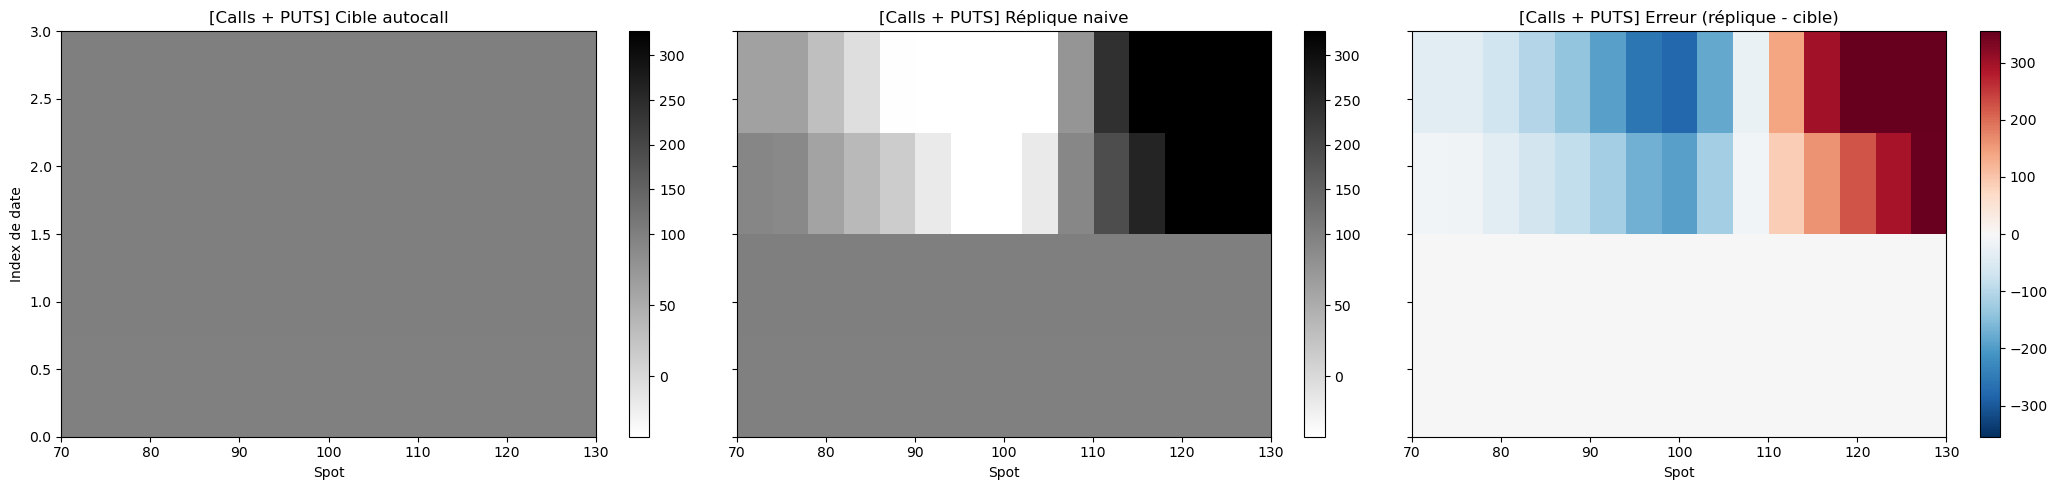

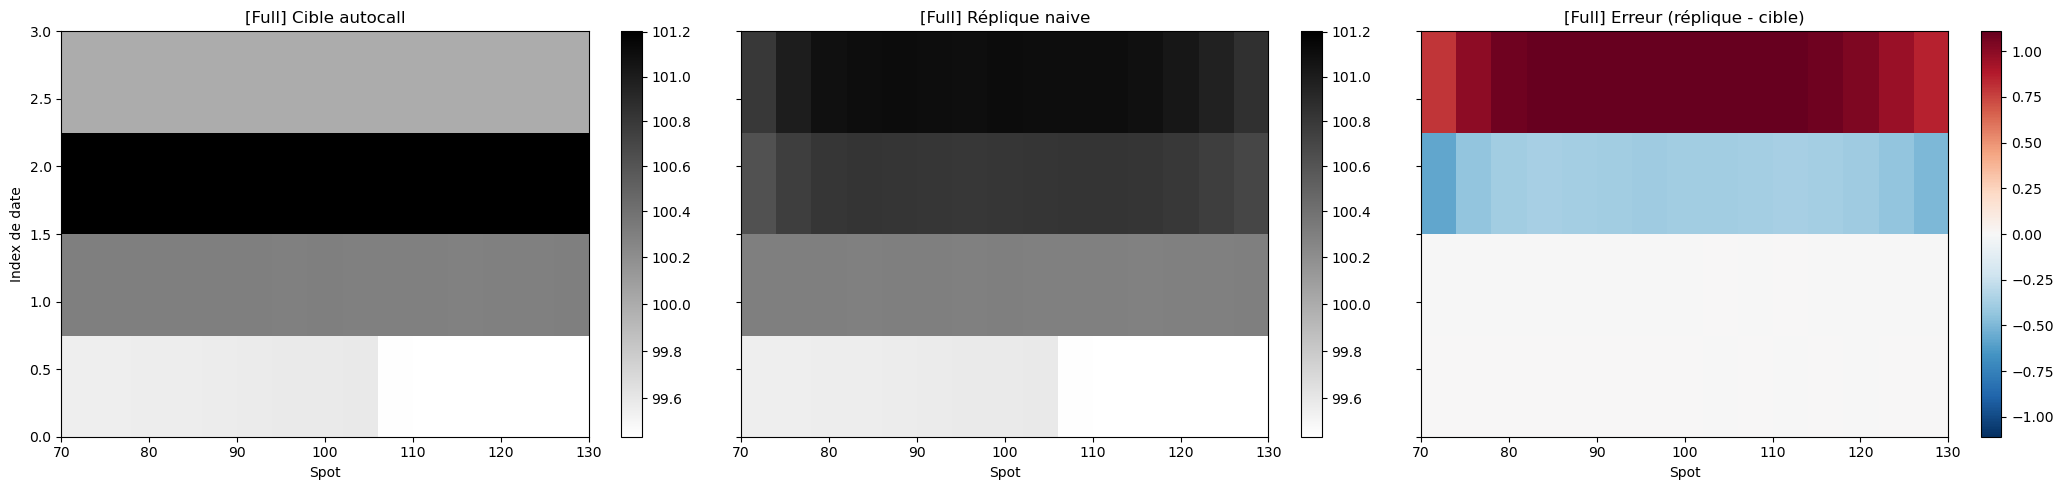

In [61]:
comparative_table = pd.DataFrame([
    {
        "family": "calls",
        "train_mae": res_calls["metrics_train"]["mae"],
        "train_rmse": res_calls["metrics_train"]["rmse"],
        "train_max_abs_error": res_calls["metrics_train"]["max_abs_error"],
        "train_mean_error": res_calls["metrics_train"]["mean_error"],
        "test_mae": res_calls["metrics_test"].get("mae", np.nan),
        "test_rmse": res_calls["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_calls["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_calls["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "calls_puts",
        "train_mae": res_calls_puts["metrics_train"]["mae"],
        "train_rmse": res_calls_puts["metrics_train"]["rmse"],
        "train_max_abs_error": res_calls_puts["metrics_train"]["max_abs_error"],
        "train_mean_error": res_calls_puts["metrics_train"]["mean_error"],
        "test_mae": res_calls_puts["metrics_test"].get("mae", np.nan),
        "test_rmse": res_calls_puts["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_calls_puts["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_calls_puts["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "full",
        "train_mae": res_full["metrics_train"]["mae"],
        "train_rmse": res_full["metrics_train"]["rmse"],
        "train_max_abs_error": res_full["metrics_train"]["max_abs_error"],
        "train_mean_error": res_full["metrics_train"]["mean_error"],
        "test_mae": res_full["metrics_test"].get("mae", np.nan),
        "test_rmse": res_full["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_full["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_full["metrics_test"].get("mean_error", np.nan),
    },
])
pd.reset_option("display.float_format")
display(comparative_table)

metrics_plot = comparative_table.copy()
metrics_plot["family"] = ["Calls", "Calls + Puts", "Full"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Train RMSE / Test RMSE
axes[0].bar(metrics_plot["family"], metrics_plot["train_rmse"], label="Train RMSE", alpha=0.8)
axes[0].bar(metrics_plot["family"], metrics_plot["test_rmse"], label="Test RMSE", alpha=0.8)
axes[0].set_title("RMSE comparatif")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

# Train MAE / Test MAE
axes[1].bar(metrics_plot["family"], metrics_plot["train_mae"], label="Train MAE", alpha=0.8)
axes[1].bar(metrics_plot["family"], metrics_plot["test_mae"], label="Test MAE", alpha=0.8)
axes[1].set_title("MAE comparatif")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

plot_benchmark_surface(res_calls["dates"],res_calls["spots"],res_calls["target_tensor"],res_calls["fitted_tensor"], title_prefix="[Calls] ")
plot_benchmark_surface(res_calls_puts["dates"],res_calls_puts["spots"],res_calls_puts["target_tensor"],res_calls_puts["fitted_tensor"], title_prefix="[Calls + PUTS] ")
plot_benchmark_surface(res_full["dates"],res_full["spots"],res_full["target_tensor"],res_full["fitted_tensor"], title_prefix="[Full] ")

,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls_puts,7.443655e-04,1.741922e-03,5.694071e-03,7.152797e-14,179.687166,240.745746,662.956421,36.487371
1,full,1.209798e-10,1.636878e-10,4.966836e-10,9.473903e-16,0.726255,0.796247,1.111206,0.316680


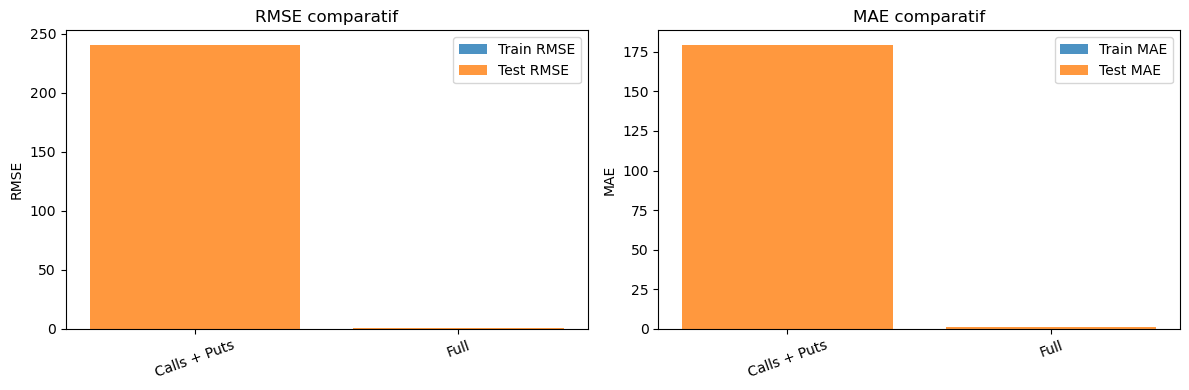

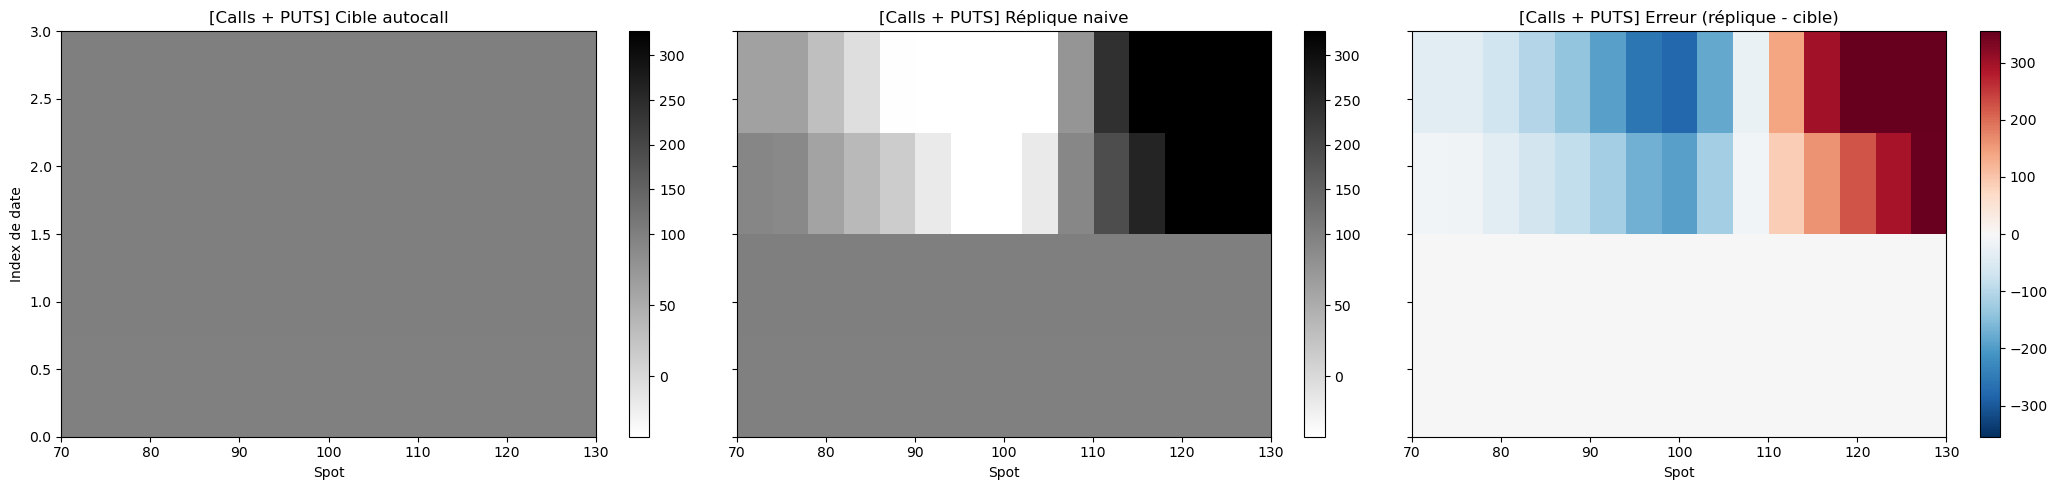

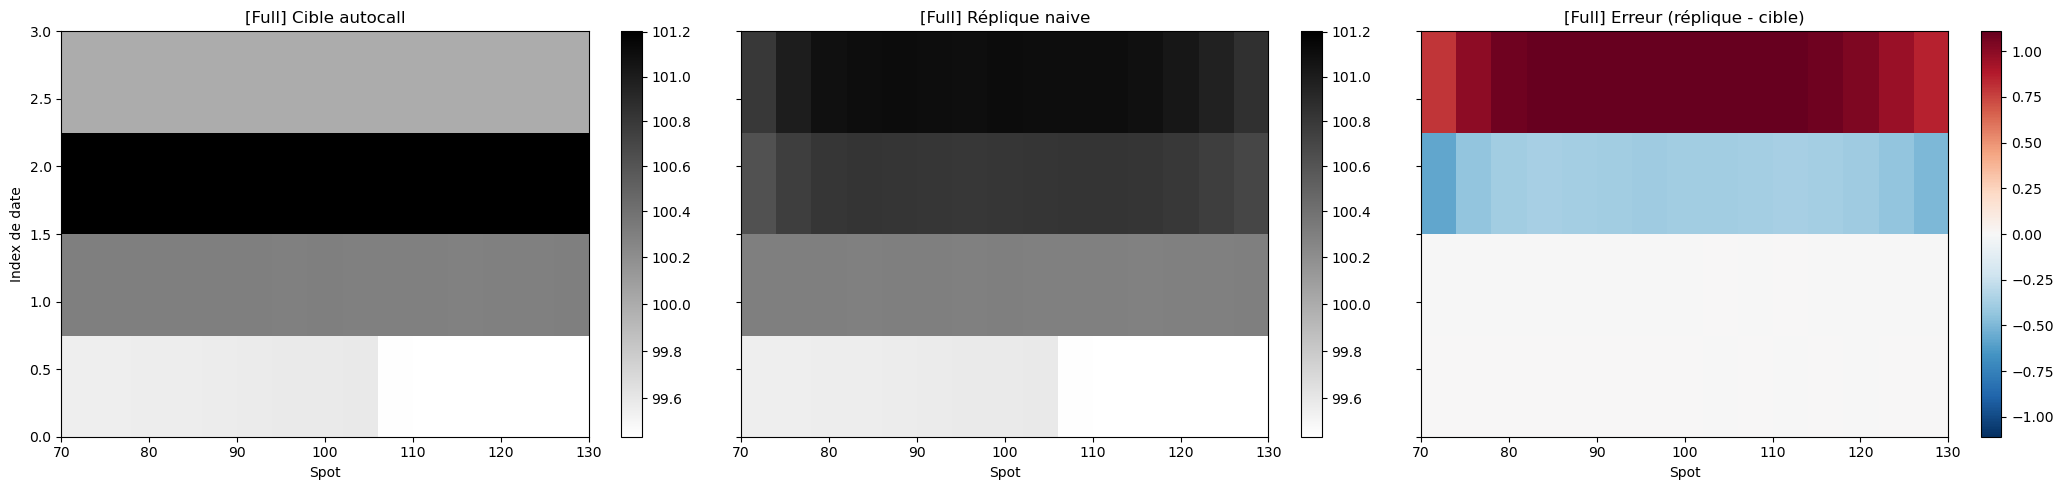

In [62]:
#tout sans le call 
# ============================================================
# EXEMPLES D'UTILISATION
# ============================================================
comparative_table = pd.DataFrame([
    {
        "family": "calls_puts",
        "train_mae": res_calls_puts["metrics_train"]["mae"],
        "train_rmse": res_calls_puts["metrics_train"]["rmse"],
        "train_max_abs_error": res_calls_puts["metrics_train"]["max_abs_error"],
        "train_mean_error": res_calls_puts["metrics_train"]["mean_error"],
        "test_mae": res_calls_puts["metrics_test"].get("mae", np.nan),
        "test_rmse": res_calls_puts["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_calls_puts["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_calls_puts["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "full",
        "train_mae": res_full["metrics_train"]["mae"],
        "train_rmse": res_full["metrics_train"]["rmse"],
        "train_max_abs_error": res_full["metrics_train"]["max_abs_error"],
        "train_mean_error": res_full["metrics_train"]["mean_error"],
        "test_mae": res_full["metrics_test"].get("mae", np.nan),
        "test_rmse": res_full["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_full["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_full["metrics_test"].get("mean_error", np.nan),
    },
])
pd.reset_option("display.float_format")
display(comparative_table)

metrics_plot = comparative_table.copy()
metrics_plot["family"] = ["Calls + Puts", "Full"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Train RMSE / Test RMSE
axes[0].bar(metrics_plot["family"], metrics_plot["train_rmse"], label="Train RMSE", alpha=0.8)
axes[0].bar(metrics_plot["family"], metrics_plot["test_rmse"], label="Test RMSE", alpha=0.8)
axes[0].set_title("RMSE comparatif")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

# Train MAE / Test MAE
axes[1].bar(metrics_plot["family"], metrics_plot["train_mae"], label="Train MAE", alpha=0.8)
axes[1].bar(metrics_plot["family"], metrics_plot["test_mae"], label="Test MAE", alpha=0.8)
axes[1].set_title("MAE comparatif")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

plot_benchmark_surface(res_calls_puts["dates"],res_calls_puts["spots"],res_calls_puts["target_tensor"],res_calls_puts["fitted_tensor"], title_prefix="[Calls + PUTS] ")
plot_benchmark_surface(res_full["dates"],res_full["spots"],res_full["target_tensor"],res_full["fitted_tensor"], title_prefix="[Full] ")

### Pourquoi utiliser `price_bs` ici plutôt que `payoff` ?

Dans cette fonction, on ne cherche pas le payoff d’une vanille à maturité, mais **l’espérance de son payoff brut au point de grille** \((t, S_t)\).

- `payoff(S_T)` donne la valeur finale de l’option **si l’on connaît le spot terminal** \(S_T\).
- `price_bs(...)` donne la **valeur actualisée** aujourd’hui :

$$
\text{price} = e^{-r\tau}\,\mathbb{E}^Q[\text{payoff}]
$$

d’où :

$$
\mathbb{E}^Q[\text{payoff}] = \text{price} \cdot e^{r\tau}
$$

Donc :

- si \(\tau \le 0\), on est à maturité ou après, et on peut utiliser directement `payoff(s)`;
- si \(\tau > 0\), `payoff(s)` ne suffit pas, car il faudrait le **spot terminal** \(S_T\), pas le spot courant \(s\).

C’est pour cela qu’on utilise `price_bs(...)` puis qu’on reconvertit en **espérance brute du payoff** avec `* exp(r * tau)`.  
C’est une façon propre et exacte de construire la matrice de régression pour les vanilles européennes.

In [64]:
# ============================================================
# BENCHMARK PAYOFF : autocall vs portefeuille de vanilles
# ============================================================

import benchmark_mean_payoff
importlib.reload(benchmark_mean_payoff)

# ------------------------------------------------------------
# 0) Helper : moyenne MC du payoff brut d'un autocall
# ------------------------------------------------------------
from benchmark_mean_payoff import mean_undiscounted_payoff_mc

# ------------------------------------------------------------
# 1) Cible : espérance du payoff brut de l'autocall sur une grille
# ------------------------------------------------------------
from benchmark_mean_payoff import autocall_meanpayoff_on_grid_mc

# ------------------------------------------------------------
# 2) Réplique : espérance de payoff brut du portefeuille de vanilles
# ------------------------------------------------------------
from benchmark_mean_payoff import vanilla_basis_expected_payoff_on_grid

# ------------------------------------------------------------
# 3) Pipeline complet : fit sur payoff brut
# ------------------------------------------------------------
from benchmark_mean_payoff import run_naive_benchmark_payoff



=== CALLS ===
Train: {'mae': 0.0008306397281354331, 'rmse': 0.0017139694283236342, 'max_abs_error': 0.005514323198994475, 'mean_error': -1.0184445879228103e-13}
Test : {'mae': 75.96869247285134, 'rmse': 108.99524877147051, 'max_abs_error': 308.87486944908466, 'mean_error': 33.55305754106207}


,name,kind,maturity_date,strike,weight
0,CASH_20260920,Cash,2026-09-20,0.0,59.436471
55,C_20270620_130.00,EuropeanCall,2027-06-20,130.0,-18.951952
35,C_20270320_100.00,EuropeanCall,2027-03-20,100.0,16.325067
41,C_20270320_130.00,EuropeanCall,2027-03-20,130.0,-13.669124
54,C_20270620_125.00,EuropeanCall,2027-06-20,125.0,-12.770802
27,C_20261220_130.00,EuropeanCall,2026-12-20,130.0,11.679380
43,C_20270620_70.00,EuropeanCall,2027-06-20,70.0,10.516997
30,C_20270320_75.00,EuropeanCall,2027-03-20,75.0,-10.263910
36,C_20270320_105.00,EuropeanCall,2027-03-20,105.0,8.080750
53,C_20270620_120.00,EuropeanCall,2027-06-20,120.0,-7.347468


=== CALLS + PUTS ===
Train: {'mae': 0.0006866650133005691, 'rmse': 0.0014721497227233105, 'max_abs_error': 0.004771668477914659, 'mean_error': -1.3121355853703182e-13}
Test : {'mae': 134.92487568097533, 'rmse': 189.16337768635765, 'max_abs_error': 535.0773116763978, 'mean_error': 43.04076325072652}


,name,kind,maturity_date,strike,weight
0,CASH_20260920,Cash,2026-09-20,0.0,665.776393
107,P_20270620_130.00,EuropeanPut,2027-06-20,130.0,-16.725484
106,C_20270620_130.00,EuropeanCall,2027-06-20,130.0,-16.651601
80,P_20270320_130.00,EuropeanPut,2027-03-20,130.0,-13.154181
79,C_20270320_130.00,EuropeanCall,2027-03-20,130.0,-13.129897
67,C_20270320_100.00,EuropeanCall,2027-03-20,100.0,12.733820
68,P_20270320_100.00,EuropeanPut,2027-03-20,100.0,12.695969
105,P_20270620_125.00,EuropeanPut,2027-06-20,125.0,-11.286388
104,C_20270620_125.00,EuropeanCall,2027-06-20,125.0,-11.241287
52,C_20261220_130.00,EuropeanCall,2026-12-20,130.0,10.576621


=== FULL ===
Train: {'mae': 9.273719570046524e-11, 'rmse': 1.384905094557426e-10, 'max_abs_error': 4.3642955915856874e-10, 'mean_error': 1.5252984060983483e-13}
Test : {'mae': 1.0845092363623172, 'rmse': 1.396100769290763, 'max_abs_error': 2.033094286557187, 'mean_error': 0.8779727579947192}


,name,kind,maturity_date,strike,weight
0,CASH_20260920,Cash,2026-09-20,0.0,107.196671
5,C_20260920_75.00,EuropeanCall,2026-09-20,75.0,0.057044
54,C_20261220_70.00,EuropeanCall,2026-12-20,70.0,-0.054676
9,C_20260920_80.00,EuropeanCall,2026-09-20,80.0,0.051361
55,P_20261220_70.00,EuropeanPut,2026-12-20,70.0,-0.047799
33,C_20260920_110.00,EuropeanCall,2026-09-20,110.0,0.046653
13,C_20260920_85.00,EuropeanCall,2026-09-20,85.0,0.044281
17,C_20260920_90.00,EuropeanCall,2026-09-20,90.0,0.037415
6,P_20260920_75.00,EuropeanPut,2026-09-20,75.0,0.036881
21,C_20260920_95.00,EuropeanCall,2026-09-20,95.0,0.032139


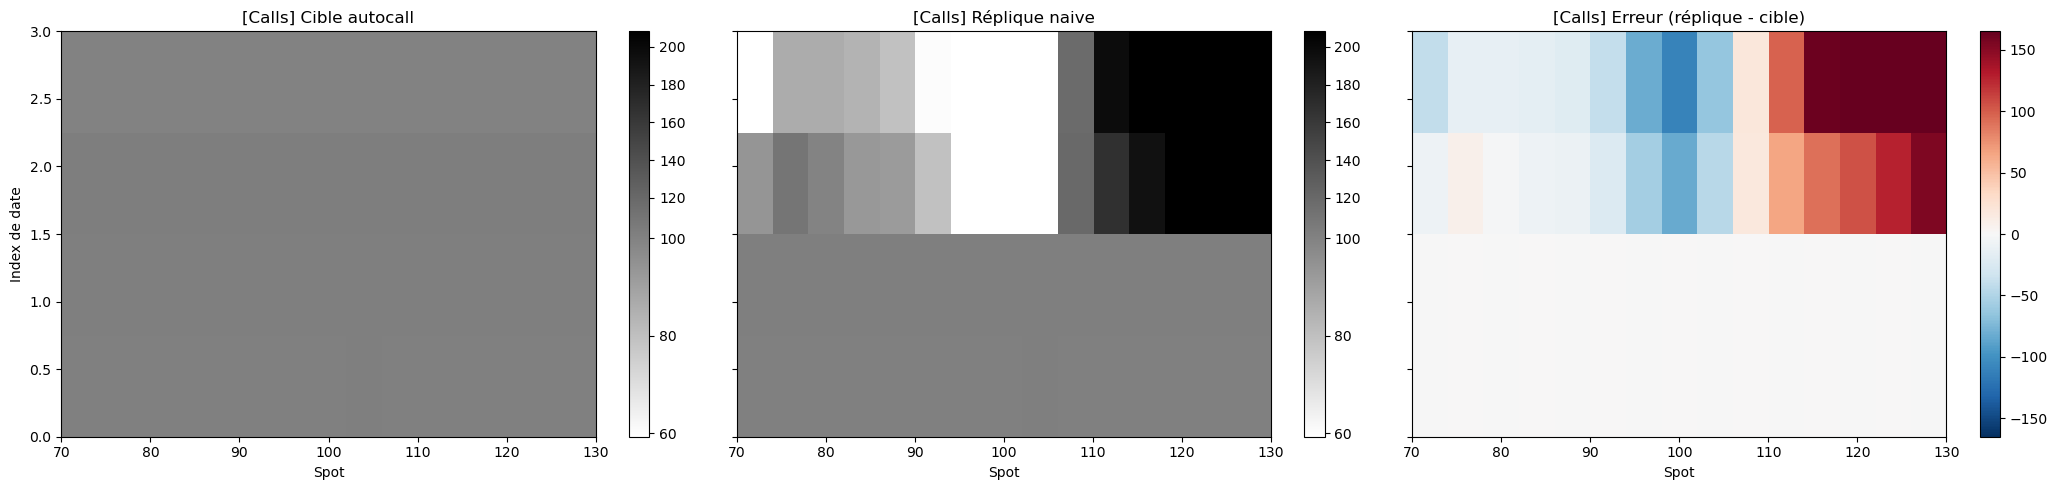

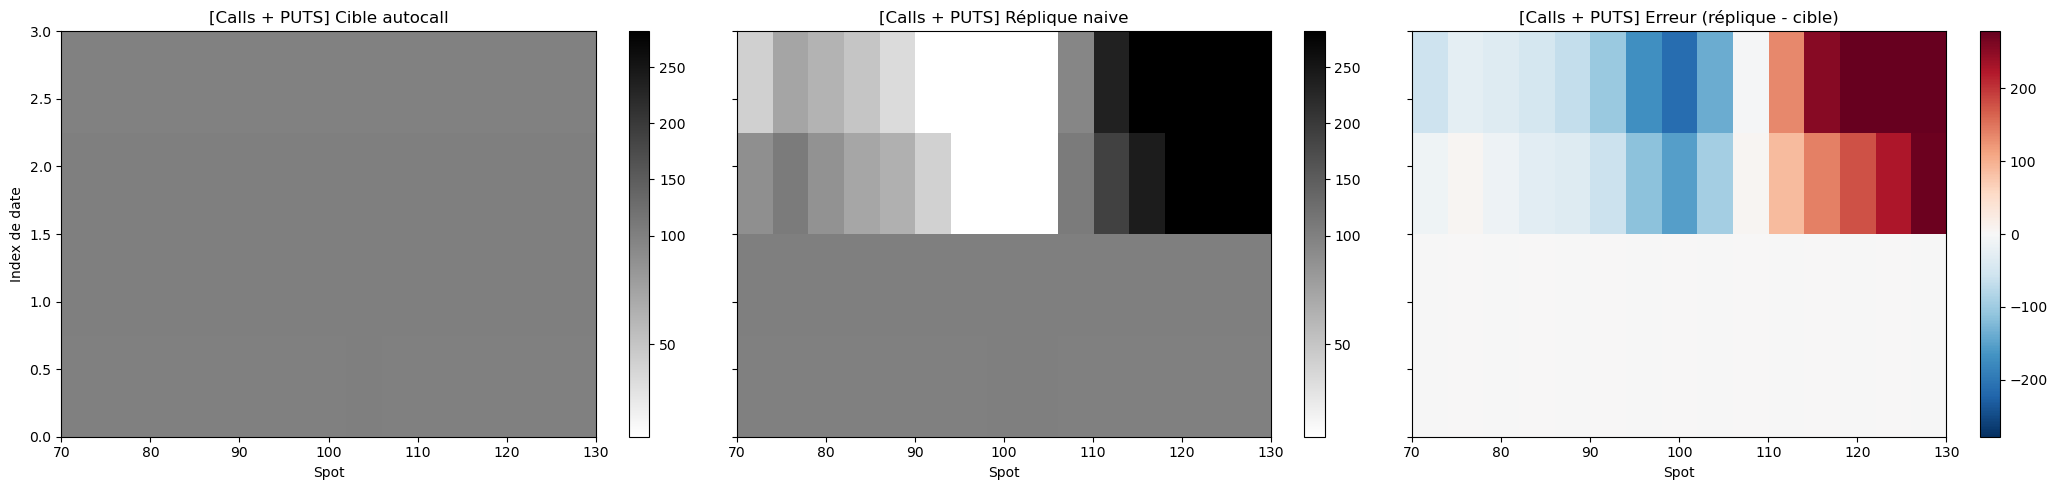

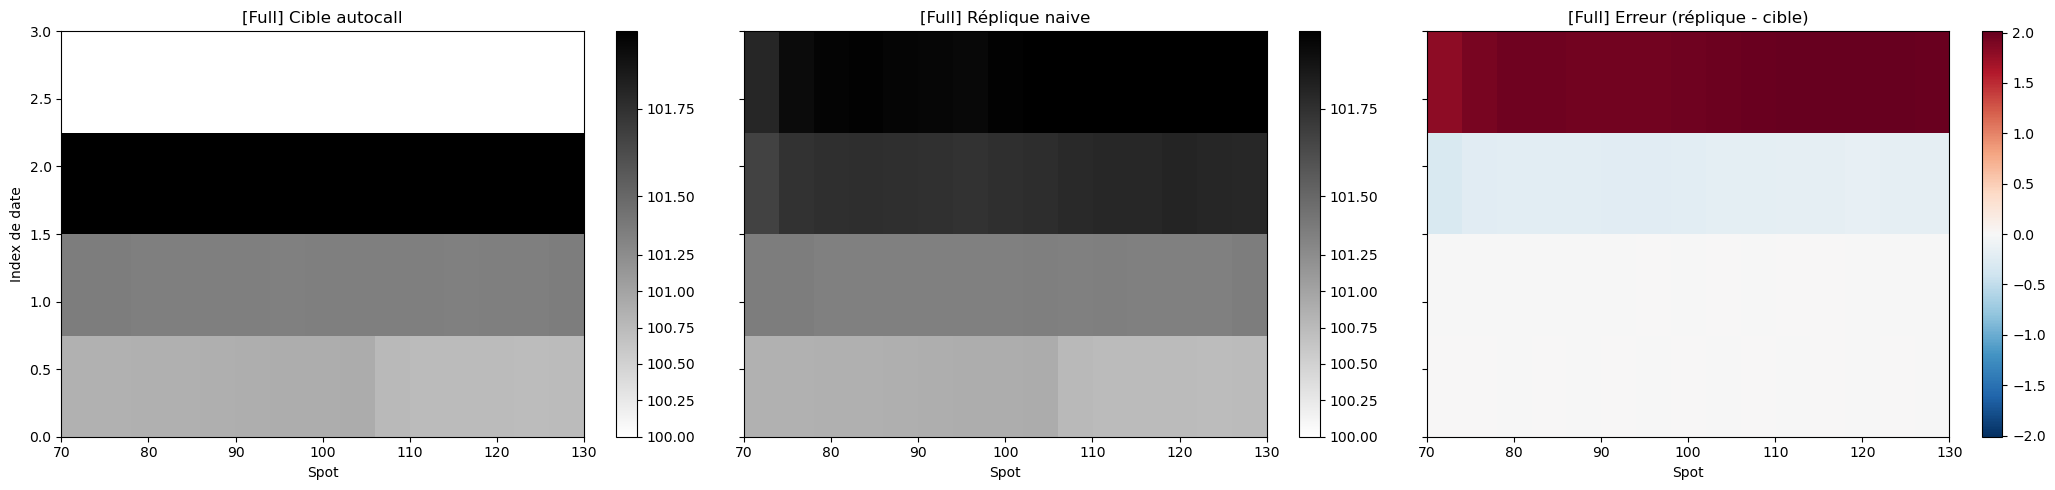

In [66]:
# ------------------------------------------------------------
# 5) Exécution
# ------------------------------------------------------------
res_payoff_calls =      run_naive_benchmark_payoff(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls",n_spots=15,n_paths=200,penalty="l2",alpha=1e-6)
res_payoff_calls_puts = run_naive_benchmark_payoff(product=prod,spot0=spot0,valuation_date=valuation_date, maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls_puts",n_spots= 15,n_paths=200,penalty="l2",alpha=1e-6)
res_payoff_full =       run_naive_benchmark_payoff(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="full",n_spots=15,n_paths=200,penalty="l2",alpha=1e-6)

print("=== CALLS ===")
print("Train:", res_payoff_calls["metrics_train"])
print("Test :", res_payoff_calls["metrics_test"])
display(res_payoff_calls["weights"].head(10))

print("=== CALLS + PUTS ===")
print("Train:", res_payoff_calls_puts["metrics_train"])
print("Test :", res_payoff_calls_puts["metrics_test"])
display(res_payoff_calls_puts["weights"].head(10))

print("=== FULL ===")
print("Train:", res_payoff_full["metrics_train"])
print("Test :", res_payoff_full["metrics_test"])
display(res_payoff_full["weights"].head(10))

plot_benchmark_surface(res_payoff_calls["dates"],res_payoff_calls["spots"],res_payoff_calls["target_tensor"],res_payoff_calls["fitted_tensor"],title_prefix="[Calls] ")
plot_benchmark_surface(res_payoff_calls_puts["dates"],res_payoff_calls_puts["spots"],res_payoff_calls_puts["target_tensor"],res_payoff_calls_puts["fitted_tensor"],title_prefix="[Calls + PUTS] ")
plot_benchmark_surface(res_payoff_full["dates"],res_payoff_full["spots"],res_payoff_full["target_tensor"],res_payoff_full["fitted_tensor"],title_prefix="[Full] ")

,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls,8.306397e-04,1.713969e-03,5.514323e-03,-1.018445e-13,75.968692,108.995249,308.874869,33.553058
1,calls_puts,6.866650e-04,1.472150e-03,4.771668e-03,-1.312136e-13,134.924876,189.163378,535.077312,43.040763
2,full,9.273720e-11,1.384905e-10,4.364296e-10,1.525298e-13,1.084509,1.396101,2.033094,0.877973


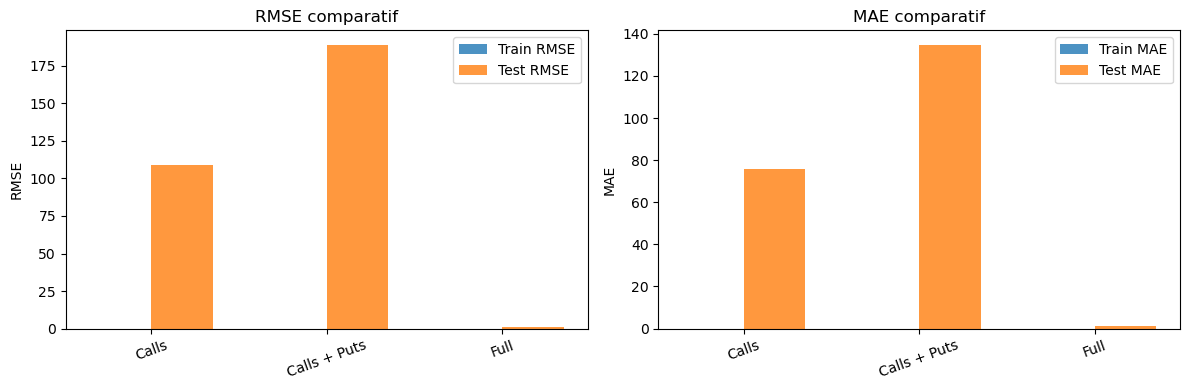

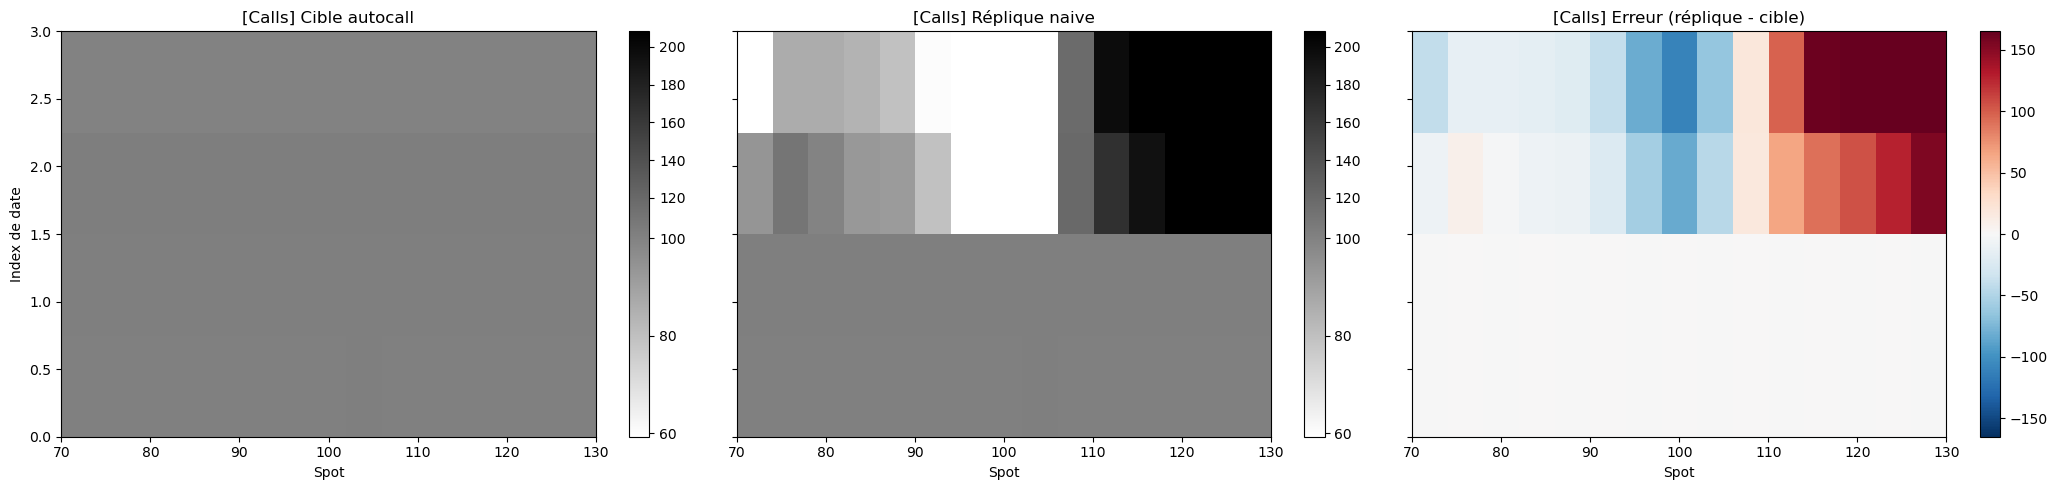

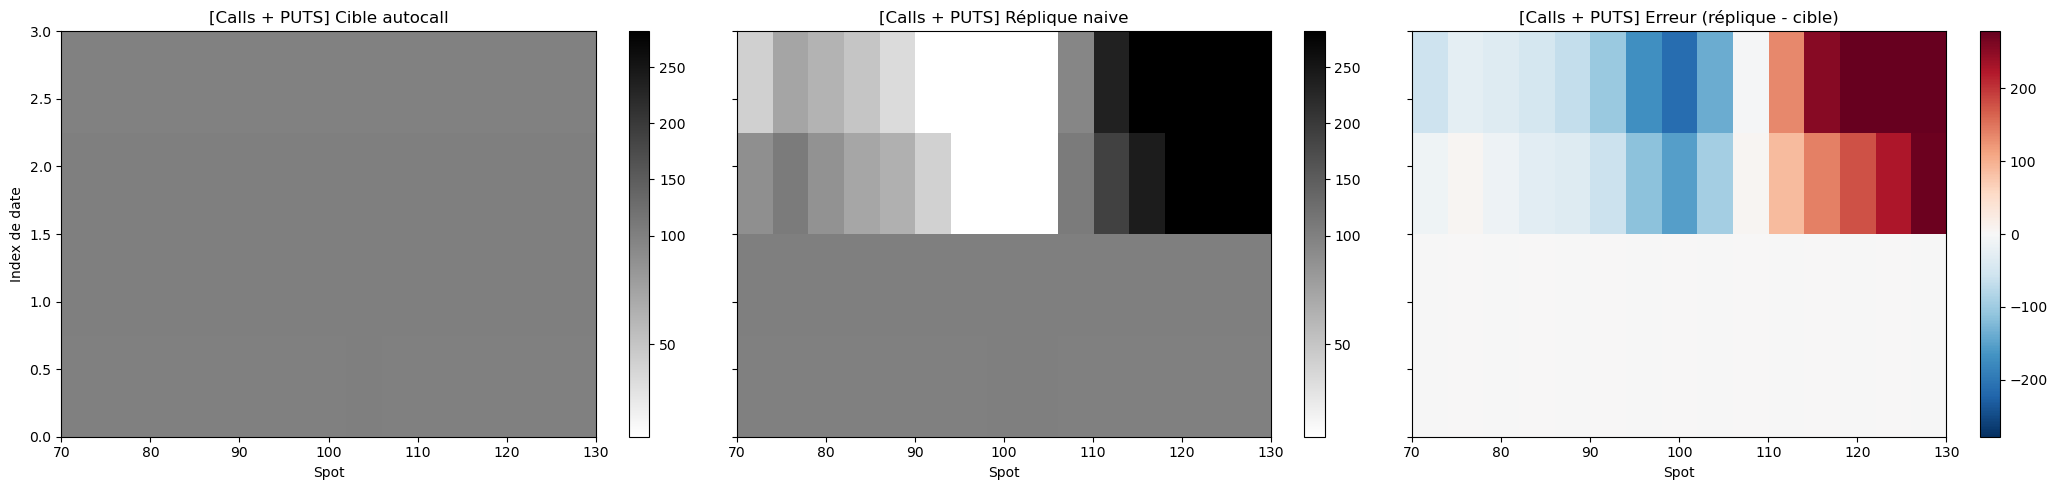

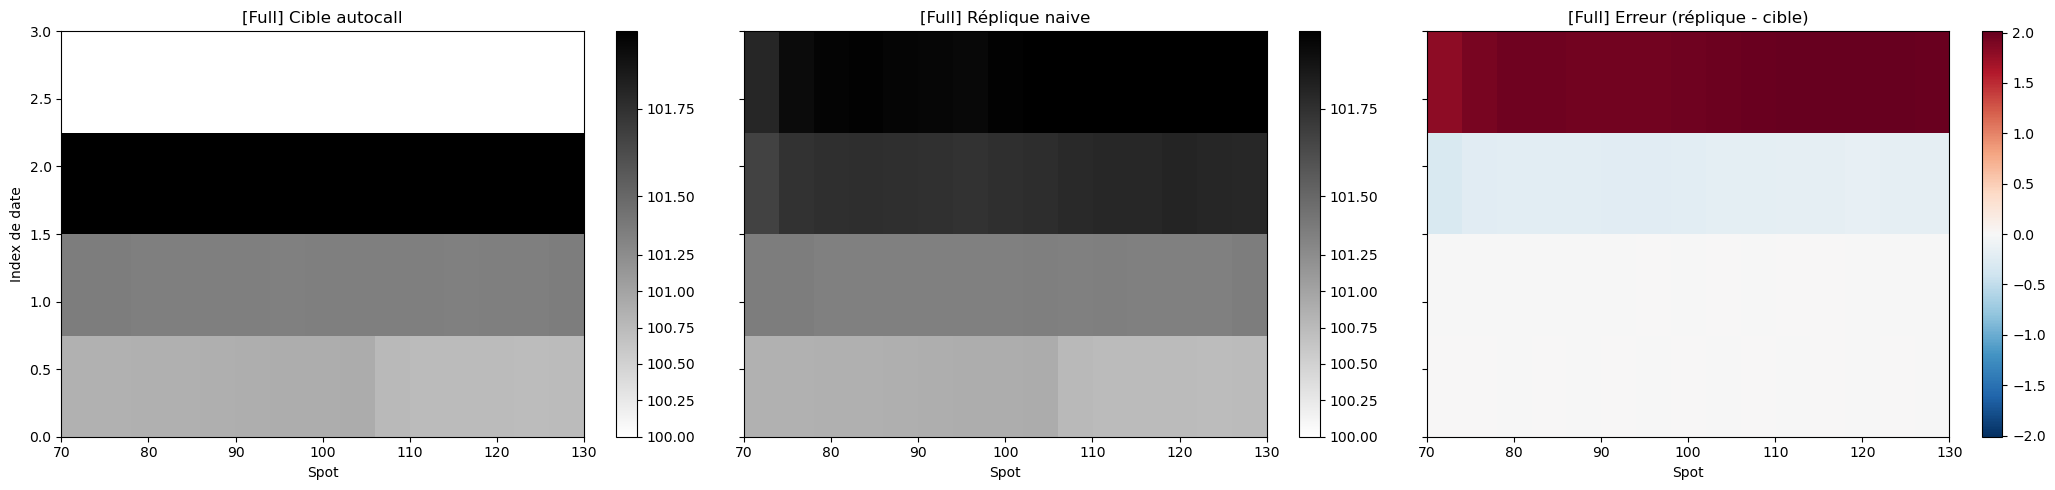

In [67]:
comparative_payoff_table = pd.DataFrame([
    {
        "family": "calls",
        "train_mae": res_payoff_calls["metrics_train"]["mae"],
        "train_rmse": res_payoff_calls["metrics_train"]["rmse"],
        "train_max_abs_error": res_payoff_calls["metrics_train"]["max_abs_error"],
        "train_mean_error": res_payoff_calls["metrics_train"]["mean_error"],
        "test_mae": res_payoff_calls["metrics_test"].get("mae", np.nan),
        "test_rmse": res_payoff_calls["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_payoff_calls["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_payoff_calls["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "calls_puts",
        "train_mae": res_payoff_calls_puts["metrics_train"]["mae"],
        "train_rmse": res_payoff_calls_puts["metrics_train"]["rmse"],
        "train_max_abs_error": res_payoff_calls_puts["metrics_train"]["max_abs_error"],
        "train_mean_error": res_payoff_calls_puts["metrics_train"]["mean_error"],
        "test_mae": res_payoff_calls_puts["metrics_test"].get("mae", np.nan),
        "test_rmse": res_payoff_calls_puts["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_payoff_calls_puts["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_payoff_calls_puts["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "full",
        "train_mae": res_payoff_full["metrics_train"]["mae"],
        "train_rmse": res_payoff_full["metrics_train"]["rmse"],
        "train_max_abs_error": res_payoff_full["metrics_train"]["max_abs_error"],
        "train_mean_error": res_payoff_full["metrics_train"]["mean_error"],
        "test_mae": res_payoff_full["metrics_test"].get("mae", np.nan),
        "test_rmse": res_payoff_full["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_payoff_full["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_payoff_full["metrics_test"].get("mean_error", np.nan),
    },
])

display(comparative_payoff_table)

metrics_plot = comparative_payoff_table.copy()
metrics_plot["family"] = ["Calls", "Calls + Puts", "Full"]

x = np.arange(len(metrics_plot))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].bar(x - width/2, metrics_plot["train_rmse"], width, label="Train RMSE", alpha=0.8)
axes[0].bar(x + width/2, metrics_plot["test_rmse"], width, label="Test RMSE", alpha=0.8)
axes[0].set_title("RMSE comparatif")
axes[0].set_ylabel("RMSE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_plot["family"], rotation=20)
axes[0].legend()

axes[1].bar(x - width/2, metrics_plot["train_mae"], width, label="Train MAE", alpha=0.8)
axes[1].bar(x + width/2, metrics_plot["test_mae"], width, label="Test MAE", alpha=0.8)
axes[1].set_title("MAE comparatif")
axes[1].set_ylabel("MAE")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_plot["family"], rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

plot_benchmark_surface(res_payoff_calls["dates"],res_payoff_calls["spots"],res_payoff_calls["target_tensor"],res_payoff_calls["fitted_tensor"],title_prefix="[Calls] ")
plot_benchmark_surface(res_payoff_calls_puts["dates"],res_payoff_calls_puts["spots"],res_payoff_calls_puts["target_tensor"],res_payoff_calls_puts["fitted_tensor"],title_prefix="[Calls + PUTS] ")
plot_benchmark_surface(res_payoff_full["dates"],res_payoff_full["spots"],res_payoff_full["target_tensor"],res_payoff_full["fitted_tensor"],title_prefix="[Full] ")

,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls_puts,6.866650e-04,1.472150e-03,4.771668e-03,-1.312136e-13,134.924876,189.163378,535.077312,43.040763
1,full,9.273720e-11,1.384905e-10,4.364296e-10,1.525298e-13,1.084509,1.396101,2.033094,0.877973


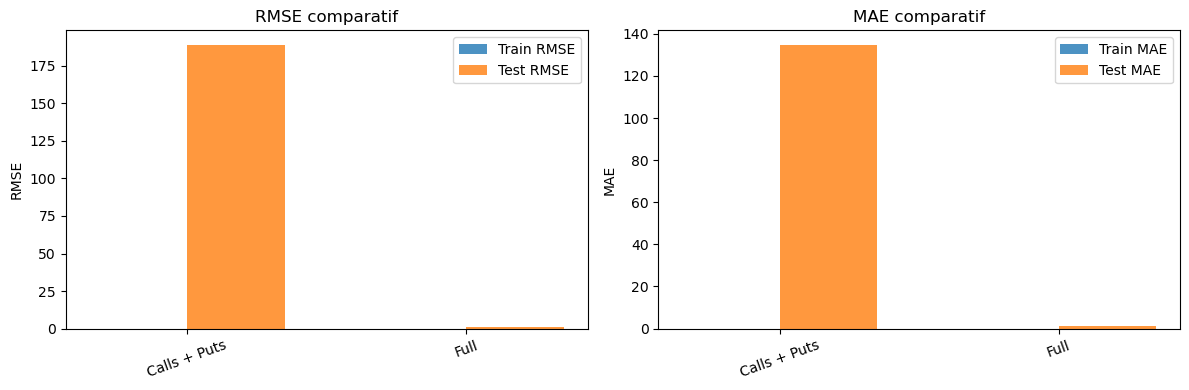

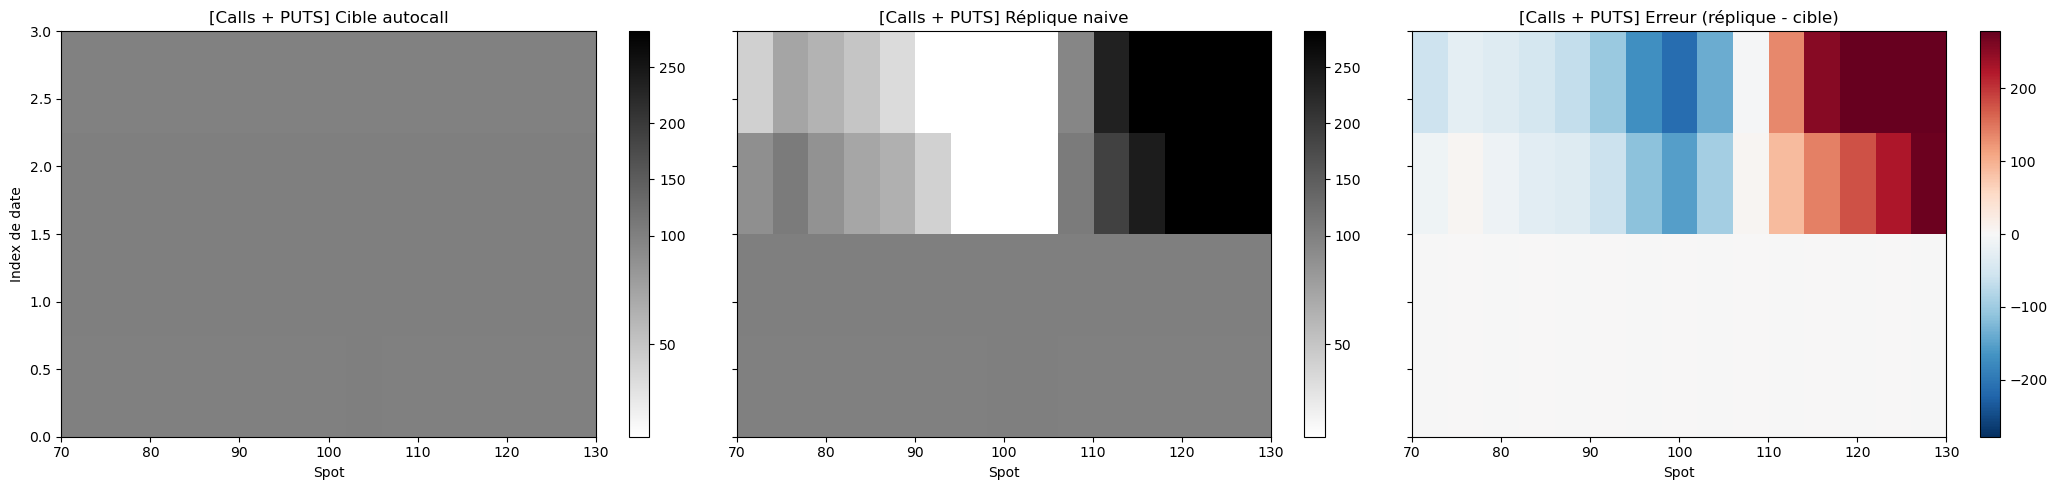

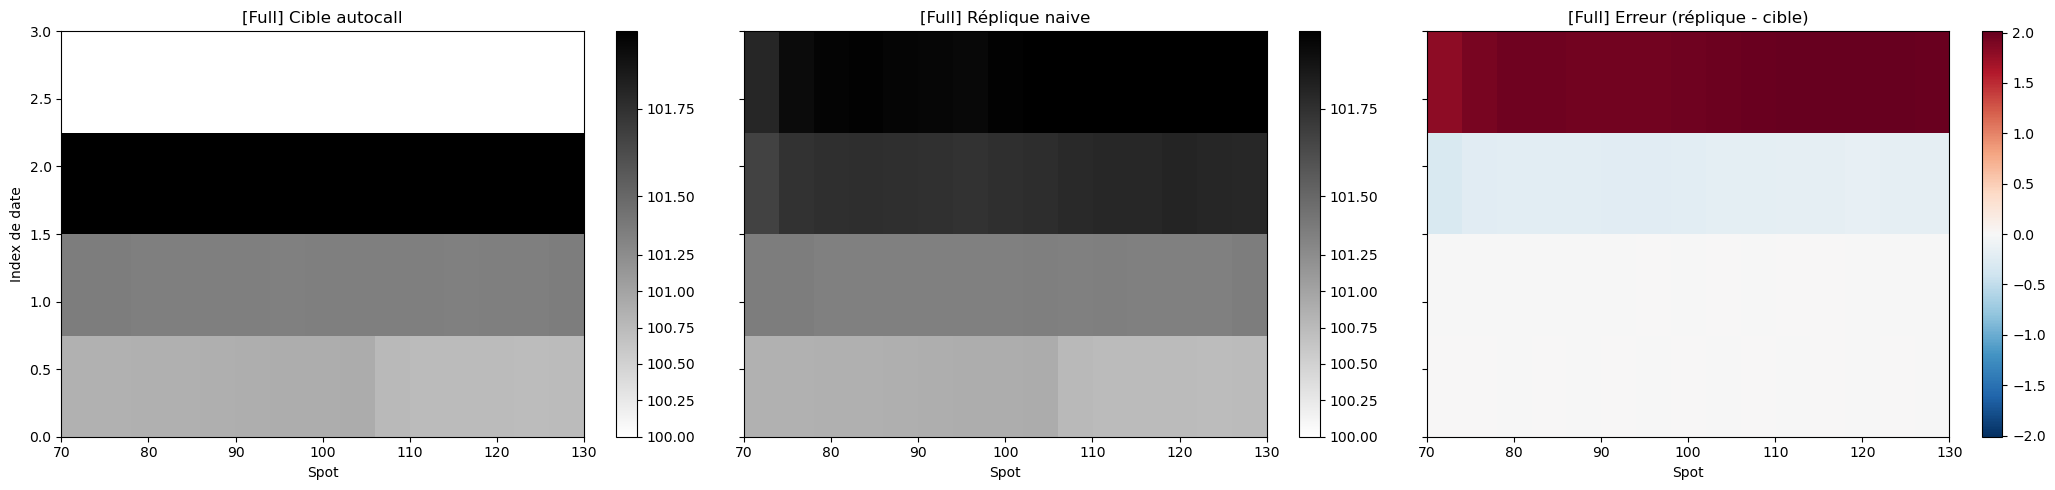

In [68]:
comparative_payoff_table = pd.DataFrame([
    {
        "family": "calls_puts",
        "train_mae": res_payoff_calls_puts["metrics_train"]["mae"],
        "train_rmse": res_payoff_calls_puts["metrics_train"]["rmse"],
        "train_max_abs_error": res_payoff_calls_puts["metrics_train"]["max_abs_error"],
        "train_mean_error": res_payoff_calls_puts["metrics_train"]["mean_error"],
        "test_mae": res_payoff_calls_puts["metrics_test"].get("mae", np.nan),
        "test_rmse": res_payoff_calls_puts["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_payoff_calls_puts["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_payoff_calls_puts["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "full",
        "train_mae": res_payoff_full["metrics_train"]["mae"],
        "train_rmse": res_payoff_full["metrics_train"]["rmse"],
        "train_max_abs_error": res_payoff_full["metrics_train"]["max_abs_error"],
        "train_mean_error": res_payoff_full["metrics_train"]["mean_error"],
        "test_mae": res_payoff_full["metrics_test"].get("mae", np.nan),
        "test_rmse": res_payoff_full["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_payoff_full["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_payoff_full["metrics_test"].get("mean_error", np.nan),
    },
])

display(comparative_payoff_table)

metrics_plot = comparative_payoff_table.copy()
metrics_plot["family"] = ["Calls + Puts", "Full"]

x = np.arange(len(metrics_plot))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].bar(x - width/2, metrics_plot["train_rmse"], width, label="Train RMSE", alpha=0.8)
axes[0].bar(x + width/2, metrics_plot["test_rmse"], width, label="Test RMSE", alpha=0.8)
axes[0].set_title("RMSE comparatif")
axes[0].set_ylabel("RMSE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_plot["family"], rotation=20)
axes[0].legend()

axes[1].bar(x - width/2, metrics_plot["train_mae"], width, label="Train MAE", alpha=0.8)
axes[1].bar(x + width/2, metrics_plot["test_mae"], width, label="Test MAE", alpha=0.8)
axes[1].set_title("MAE comparatif")
axes[1].set_ylabel("MAE")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_plot["family"], rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

plot_benchmark_surface(res_payoff_calls_puts["dates"],res_payoff_calls_puts["spots"],res_payoff_calls_puts["target_tensor"],res_payoff_calls_puts["fitted_tensor"],title_prefix="[Calls + PUTS] ")
plot_benchmark_surface(res_payoff_full["dates"],res_payoff_full["spots"],res_payoff_full["target_tensor"],res_payoff_full["fitted_tensor"],title_prefix="[Full] ")

In [70]:
# ============================================================
# BENCHMARK PAYOFF PATHWISE : mêmes trajectoires pour tout
# ============================================================

# ------------------------------------------------------------
# 0) Payoff actualisé de l'autocall sur une trajectoire donnée
# ------------------------------------------------------------
from monte_carlo import autocall_discounted_payoff_from_path

# ------------------------------------------------------------
# 1) Payoff actualisé d'une vanille sur une trajectoire donnée
# ------------------------------------------------------------
from benchmark_payoff import vanilla_discounted_payoff_from_path

# ------------------------------------------------------------
# 2) Construction du dataset pathwise
# ------------------------------------------------------------
from benchmark_payoff import build_pathwise_payoff_dataset

# ------------------------------------------------------------
# 3) Pipeline complet : benchmark payoff pathwise
# ------------------------------------------------------------
from benchmark_payoff import run_naive_benchmark_payoff_pathwise

# ------------------------------------------------------------
# 4) Affichage : version lisible et interprétable
# ------------------------------------------------------------
from benchmark_payoff import plot_pathwise_benchmark

Train: {'mae': 1.7863837755018352, 'rmse': 3.536043597722688, 'max_abs_error': 16.63596536289758, 'mean_error': 5.376440033918091e-14}
Test : {'mae': 2.2094694684116405, 'rmse': 4.868901134833547, 'max_abs_error': 26.616097707577296, 'mean_error': -0.7521845271046795}


,name,kind,maturity_date,strike,weight
0,CASH_20260920,Cash,2026-09-20,0.0,66.618720
43,C_20270620_70.00,EuropeanCall,2027-06-20,70.0,3.102224
44,C_20270620_75.00,EuropeanCall,2027-06-20,75.0,-2.494920
29,C_20270320_70.00,EuropeanCall,2027-03-20,70.0,1.263098
1,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,-0.952476
19,C_20261220_90.00,EuropeanCall,2026-12-20,90.0,-0.896948
4,C_20260920_85.00,EuropeanCall,2026-09-20,85.0,0.867910
6,C_20260920_95.00,EuropeanCall,2026-09-20,95.0,-0.738574
18,C_20261220_85.00,EuropeanCall,2026-12-20,85.0,-0.736495
32,C_20270320_85.00,EuropeanCall,2027-03-20,85.0,-0.731524


Train: {'mae': 1.7631367831692717, 'rmse': 3.4749506009300455, 'max_abs_error': 19.320126314548617, 'mean_error': -4.1922021409845913e-14}
Test : {'mae': 2.183217836106649, 'rmse': 4.793777189384343, 'max_abs_error': 26.343092109235215, 'mean_error': -0.7178375266997002}


,name,kind,maturity_date,strike,weight
0,CASH_20260920,Cash,2026-09-20,0.0,97.289149
82,C_20270620_70.00,EuropeanCall,2027-06-20,70.0,1.117886
85,P_20270620_75.00,EuropeanPut,2027-06-20,75.0,-1.092278
83,P_20270620_70.00,EuropeanPut,2027-06-20,70.0,1.081073
84,C_20270620_75.00,EuropeanCall,2027-06-20,75.0,-1.055985
29,P_20261220_70.00,EuropeanPut,2026-12-20,70.0,-0.952438
28,C_20261220_70.00,EuropeanCall,2026-12-20,70.0,-0.848880
30,C_20261220_75.00,EuropeanCall,2026-12-20,75.0,0.811328
31,P_20261220_75.00,EuropeanPut,2026-12-20,75.0,0.708300
8,P_20260920_85.00,EuropeanPut,2026-09-20,85.0,0.698635


Train: {'mae': 1.5511450362968273, 'rmse': 2.80749430344304, 'max_abs_error': 15.461809202776394, 'mean_error': -1.0691976404771031e-14}
Test : {'mae': 3.392832775307005, 'rmse': 5.586845459517522, 'max_abs_error': 27.285219028860595, 'mean_error': -1.07491853265777}


,name,kind,maturity_date,strike,weight
0,CASH_20260920,Cash,2026-09-20,0.0,47.195592
7,BC_20260920_75.00,BinaryCall,2026-09-20,75.0,13.326126
8,BP_20260920_75.00,BinaryPut,2026-09-20,75.0,-13.326116
20,BP_20260920_90.00,BinaryPut,2026-09-20,90.0,-7.718098
19,BC_20260920_90.00,BinaryCall,2026-09-20,90.0,7.718073
16,BP_20260920_85.00,BinaryPut,2026-09-20,85.0,-5.694505
15,BC_20260920_85.00,BinaryCall,2026-09-20,85.0,5.694499
117,BC_20270320_80.00,BinaryCall,2027-03-20,80.0,-4.935005
118,BP_20270320_80.00,BinaryPut,2027-03-20,80.0,4.934988
6,P_20260920_75.00,EuropeanPut,2026-09-20,75.0,4.549571


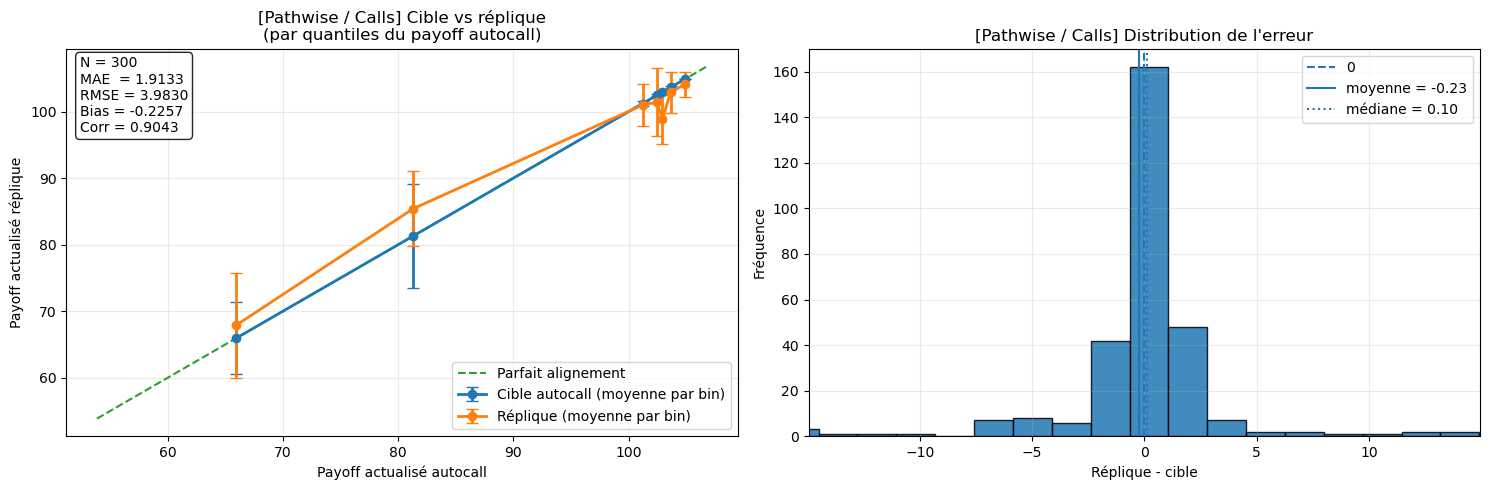

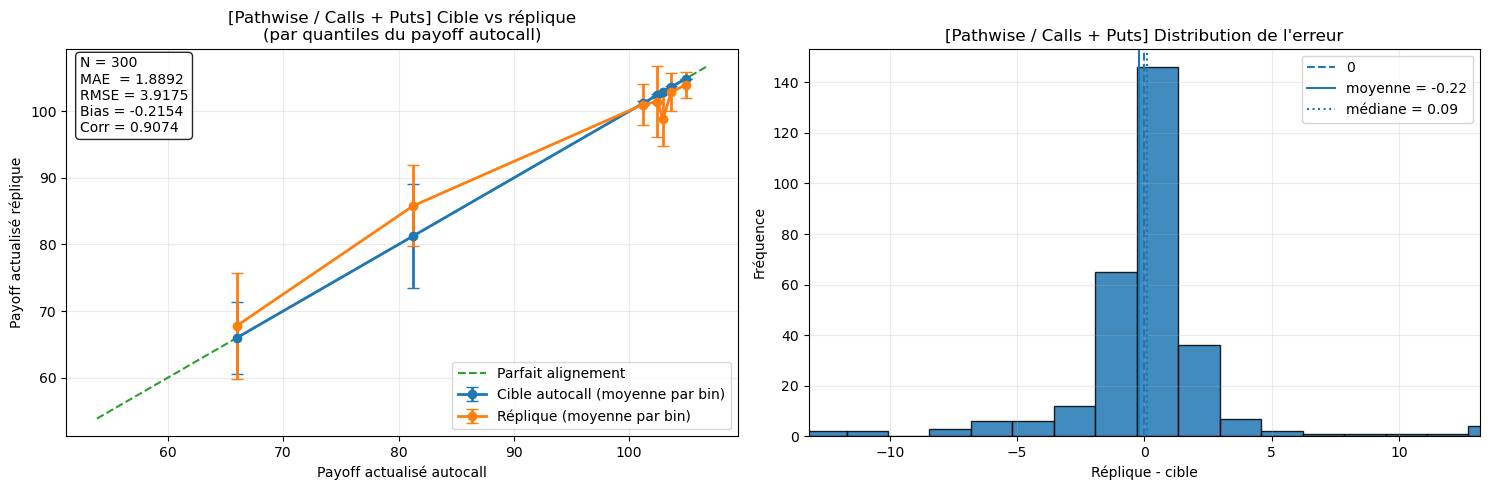

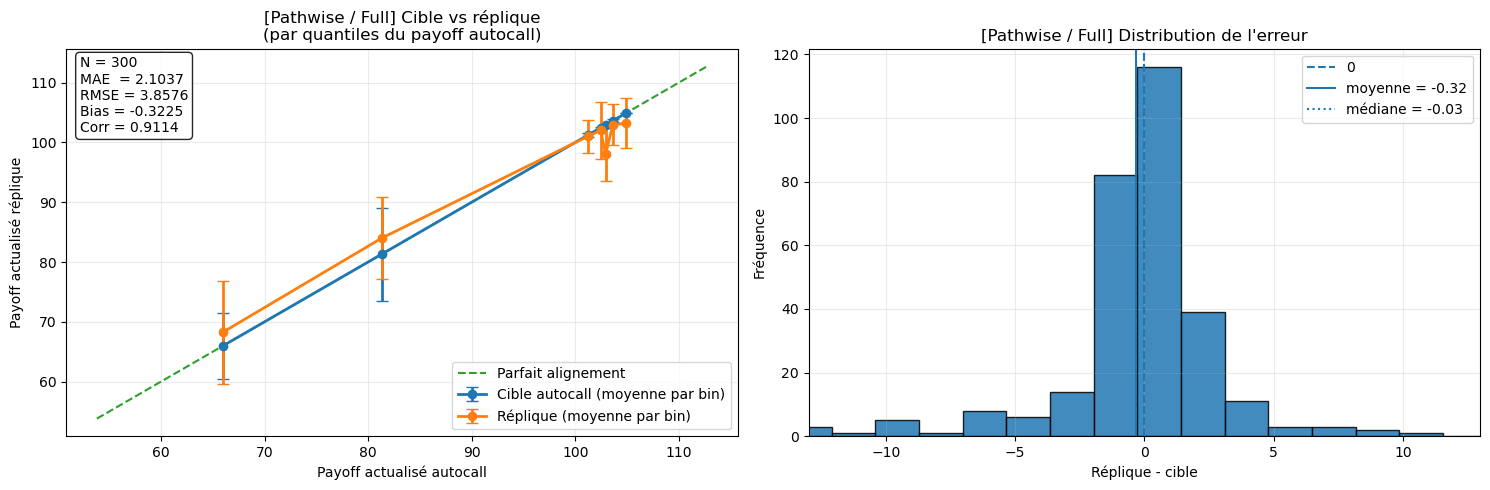

In [73]:
# ------------------------------------------------------------
# 5) Exécution
# ------------------------------------------------------------

res_path_calls = run_naive_benchmark_payoff_pathwise(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls",n_paths=300,penalty="l2",alpha=1e-6)
res_path_calls_puts = run_naive_benchmark_payoff_pathwise(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls_puts",n_paths=300,penalty="l2",alpha=1e-6)
res_path_full = run_naive_benchmark_payoff_pathwise(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="full",n_paths=300,penalty="l2",alpha=1e-6)

print("Train:", res_path_calls["metrics_train"])
print("Test :", res_path_calls["metrics_test"])
display(res_path_calls["weights"].head(10))

print("Train:", res_path_calls_puts["metrics_train"])
print("Test :", res_path_calls_puts["metrics_test"])
display(res_path_calls_puts["weights"].head(10))

print("Train:", res_path_full["metrics_train"])
print("Test :", res_path_full["metrics_test"])
display(res_path_full["weights"].head(10))

plot_pathwise_benchmark(res_path_calls["y"],res_path_calls["replica"],title_prefix="[Pathwise / Calls] ")
plot_pathwise_benchmark(res_path_calls_puts["y"],res_path_calls_puts["replica"],title_prefix="[Pathwise / Calls + Puts] ")
plot_pathwise_benchmark(res_path_full["y"],res_path_full["replica"],title_prefix="[Pathwise / Full] ")


In [75]:
# ============================================================
# BENCHMARK COURBE PATHWISE :
# valeur de l'autocall et du réplica le long d'une trajectoire
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from benchmark_general import build_naive_vanilla_basis, fit_linear, benchmark_metrics
from monte_carlo import simulate_gbm_path
from products_core import AutocallProduct, VanillaProduct, _year_fraction


# ------------------------------------------------------------
# 0) Courbe cible : valeur actualisée de l'autocall le long d'un path
# ------------------------------------------------------------
def autocall_value_curve_on_path(
    product: AutocallProduct,
    path: pd.Series,
    valuation_date: str | pd.Timestamp,
    rate: float,
) -> pd.Series:
    """
    Retourne la courbe de valeur actualisée de l'autocall le long d'une trajectoire.

    On calcule d'abord les cashflows complets de l'autocall sur le path,
    puis pour chaque date t on valorise uniquement les cashflows futurs.
    """
    valuation_date = pd.Timestamp(valuation_date)
    path = path.sort_index().dropna()

    # Cashflows complets du produit sur cette trajectoire
    full_res = product.compute_autocall_payoff(path, start_date=valuation_date)
    cashflows = full_res["cashflows"].copy()
    cashflows["date"] = pd.to_datetime(cashflows["date"])

    curve_dates = path.index[path.index >= valuation_date]
    values = np.empty(len(curve_dates), dtype=float)

    for i, d in enumerate(curve_dates):
        future_cf = cashflows.loc[cashflows["date"] >= d]
        if future_cf.empty:
            values[i] = 0.0
            continue

        tt = future_cf["date"].apply(lambda x: _year_fraction(d, pd.Timestamp(x))).to_numpy(dtype=float)
        amounts = future_cf["amount"].to_numpy(dtype=float)
        values[i] = float(np.sum(amounts * np.exp(-rate * tt)))

    return pd.Series(values, index=curve_dates, name="autocall_value")


# ------------------------------------------------------------
# 1) Courbe réplique : valeur du portefeuille de vanilles le long d'un path
# ------------------------------------------------------------
def vanilla_portfolio_value_curve_on_path(
    vanillas: list[VanillaProduct],
    weights: np.ndarray,
    path: pd.Series,
    valuation_date: str | pd.Timestamp,
    rate: float,
    dividend_yield: float,
    vol: float,
) -> pd.Series:
    """
    Retourne la courbe de valeur du portefeuille de vanilles le long d'une trajectoire.

    À chaque date t :
    - on prend le spot observé sur le path,
    - on price chaque vanille avec Black-Scholes,
    - on somme avec les poids appris.
    """
    valuation_date = pd.Timestamp(valuation_date)
    path = path.sort_index().dropna()

    curve_dates = path.index[path.index >= valuation_date]
    values = np.empty(len(curve_dates), dtype=float)

    w = np.asarray(weights, dtype=float).reshape(-1)

    for i, d in enumerate(curve_dates):
        s = float(path.loc[d])
        pv = 0.0
        for weight, v in zip(w, vanillas):
            pv += float(weight) * float(
                v.price_bs(
                    spot=s,
                    valuation_date=d,
                    rate=rate,
                    dividend_yield=dividend_yield,
                    vol=vol,
                )
            )
        values[i] = pv

    return pd.Series(values, index=curve_dates, name="replica_value")


# ------------------------------------------------------------
# 2) Dataset pathwise temporel :
#    chaque observation = (path, date)
# ------------------------------------------------------------
def build_timewise_curve_dataset(
    product: AutocallProduct,
    vanillas: list[VanillaProduct],
    spot0: float,
    valuation_date: str | pd.Timestamp,
    maturity_date: str | pd.Timestamp,
    rate: float,
    dividend_yield: float,
    vol: float,
    n_paths: int = 2000,
    seed: int = 42,
) -> list[dict[str, object]]:
    """
    Construit une liste de trajectoires.
    Pour chaque trajectoire, on stocke :
    - le path simulé
    - la courbe cible autocall
    - la matrice des features vanilles le long du temps
    """
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    data = []

    for p in range(n_paths):
        seed_p = None if seed is None else seed + p

        path = simulate_gbm_path(
            spot0=spot0,
            start_date=valuation_date,
            end_date=maturity_date,
            rate=rate,
            dividend_yield=dividend_yield,
            vol=vol,
            seed=seed_p,
        )

        y_curve = autocall_value_curve_on_path(
            product=product,
            path=path,
            valuation_date=valuation_date,
            rate=rate,
        )

        curve_dates = y_curve.index
        X_curve = np.empty((len(curve_dates), len(vanillas)), dtype=float)

        for i, d in enumerate(curve_dates):
            s = float(path.loc[d])
            for j, v in enumerate(vanillas):
                X_curve[i, j] = float(
                    v.price_bs(
                        spot=s,
                        valuation_date=d,
                        rate=rate,
                        dividend_yield=dividend_yield,
                        vol=vol,
                    )
                )

        data.append(
            {
                "path": path,
                "dates": curve_dates,
                "X_curve": X_curve,
                "y_curve": y_curve.to_numpy(dtype=float),
            }
        )

    return data


# ------------------------------------------------------------
# 3) Pipeline complet : fit sur courbes temporelles
# ------------------------------------------------------------
def run_naive_benchmark_curve(
    product: AutocallProduct,
    spot0: float,
    valuation_date: str | pd.Timestamp,
    maturity_date: str | pd.Timestamp,
    rate: float,
    dividend_yield: float,
    vol: float,
    family: str,
    n_paths: int = 2000,
    spot_min_mult: float = 0.70,
    spot_max_mult: float = 1.30,
    penalty: str = "l2",
    alpha: float = 1e-8,
    train_frac: float = 0.7,
    seed: int = 42,
) -> dict[str, object]:
    """
    Réplique une courbe de valeur le long d'une trajectoire.

    On apprend des poids fixes sur des observations (path, date),
    puis on compare la courbe cible et la courbe réplique sur des paths de test.
    """
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    vanillas = build_naive_vanilla_basis(
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        product=product,
        strike_step=5.0,
        strike_min_mult=spot_min_mult,
        strike_max_mult=spot_max_mult,
        family=family,
    )

    dataset = build_timewise_curve_dataset(
        product=product,
        vanillas=vanillas,
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        rate=rate,
        dividend_yield=dividend_yield,
        vol=vol,
        n_paths=n_paths,
        seed=seed,
    )

    split = int(train_frac * n_paths)
    split = max(1, min(split, n_paths - 1 if n_paths > 1 else 1))

    train_set = dataset[:split]
    test_set = dataset[split:]

    # Flatten train
    X_train = np.vstack([d["X_curve"] for d in train_set])
    y_train = np.concatenate([d["y_curve"] for d in train_set])

    # Flatten test
    if len(test_set) > 0:
        X_test = np.vstack([d["X_curve"] for d in test_set])
        y_test = np.concatenate([d["y_curve"] for d in test_set])
    else:
        X_test = np.empty((0, len(vanillas)))
        y_test = np.empty((0,))

    w = fit_linear(X_train, y_train, penalty=penalty, alpha=alpha)

    pred_train = X_train @ w
    pred_test = X_test @ w if len(X_test) > 0 else np.array([])

    metrics_train = benchmark_metrics(y_train, pred_train)
    metrics_test = benchmark_metrics(y_test, pred_test) if len(X_test) > 0 else {}

    weights = pd.DataFrame(
        {
            "name": [v.name for v in vanillas],
            "kind": [v.__class__.__name__ for v in vanillas],
            "maturity_date": [pd.Timestamp(v.maturity_date) for v in vanillas],
            "strike": [float(v.strike) for v in vanillas],
            "weight": w,
        }
    ).sort_values("weight", key=lambda s: s.abs(), ascending=False)

    return {
        "vanillas": vanillas,
        "weights": weights,
        "w": w,
        "train_set": train_set,
        "test_set": test_set,
        "metrics_train": metrics_train,
        "metrics_test": metrics_test,
        "family": family,
        "split": split,
    }


# ------------------------------------------------------------
# 4) Plot lisible : courbes dans le temps
# ------------------------------------------------------------
def plot_timewise_curve_benchmark(
    dates: pd.DatetimeIndex,
    target_curve: np.ndarray,
    replica_curve: np.ndarray,
    title_prefix: str = ""):
    """
    Affiche la courbe cible et la courbe réplique sur une trajectoire.
    """
    dates = pd.to_datetime(dates)
    target_curve = np.asarray(target_curve, dtype=float).reshape(-1)
    replica_curve = np.asarray(replica_curve, dtype=float).reshape(-1)
    err = replica_curve - target_curve

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(dates, target_curve, label="Cible autocall", linewidth=2)
    axes[0].plot(dates, replica_curve, label="Réplique", linewidth=2)
    axes[0].set_title(f"{title_prefix}Courbe de valeur le long du path")
    axes[0].set_ylabel("Valeur actualisée")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(dates, err, label="Erreur", linewidth=1.5)
    axes[1].axhline(0.0, linestyle="--", linewidth=1)
    axes[1].set_ylabel("Réplique - cible")
    axes[1].set_xlabel("Date")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

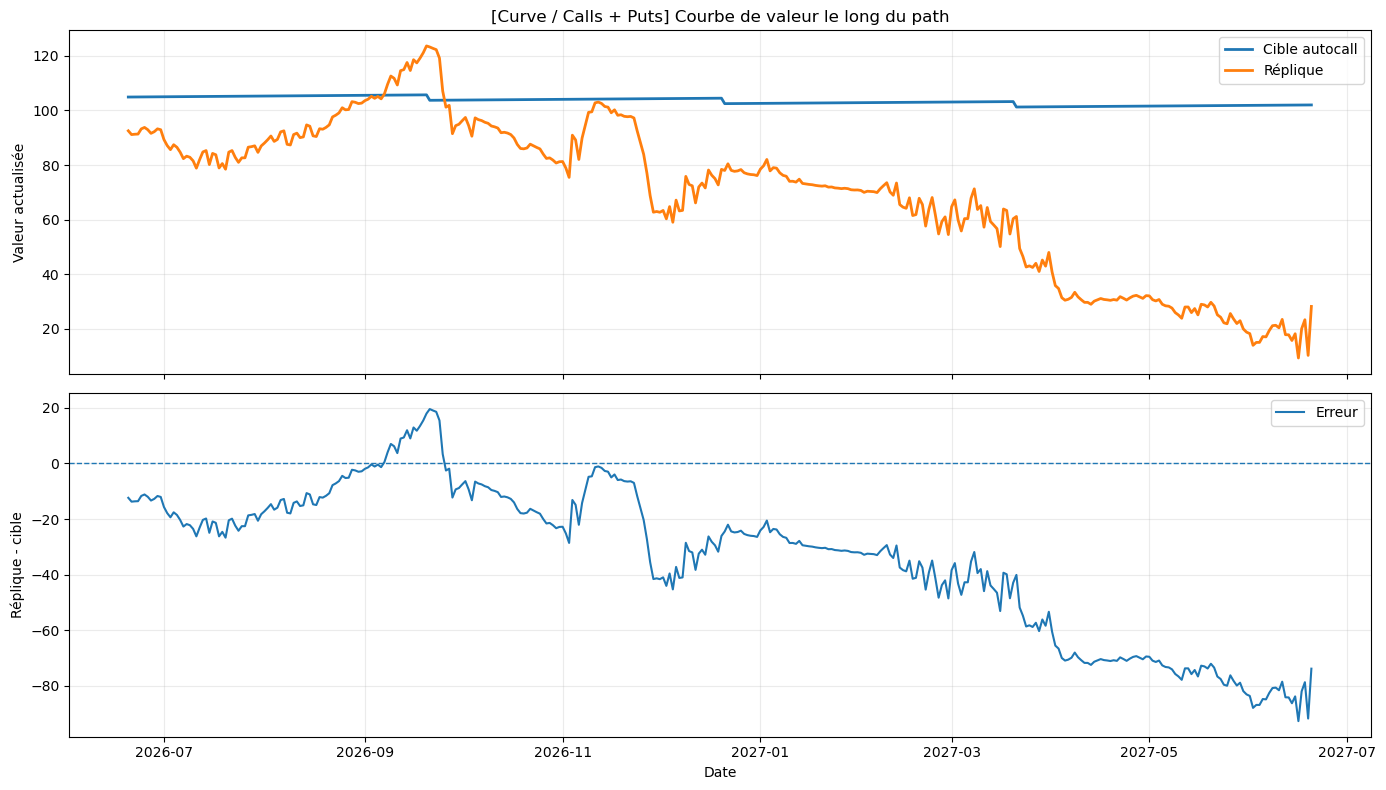

In [78]:
res_curve = run_naive_benchmark_curve(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls_puts",n_paths=100,penalty="l2",alpha=1e-6)
test_path = simulate_gbm_path(spot0=spot0,start_date=pd.Timestamp(valuation_date),end_date=pd.Timestamp(maturity_date),rate=rate,dividend_yield=dividend_yield,vol=vol)
target_curve = autocall_value_curve_on_path(product=prod,path=test_path,valuation_date=valuation_date,rate=rate)
replica_curve = vanilla_portfolio_value_curve_on_path(vanillas=res_curve["vanillas"],weights=res_curve["w"],path=test_path,valuation_date=valuation_date,rate=rate,dividend_yield=dividend_yield,vol=vol)
plot_timewise_curve_benchmark(target_curve.index,target_curve.to_numpy(),replica_curve.to_numpy(),title_prefix="[Curve / Calls + Puts] ")


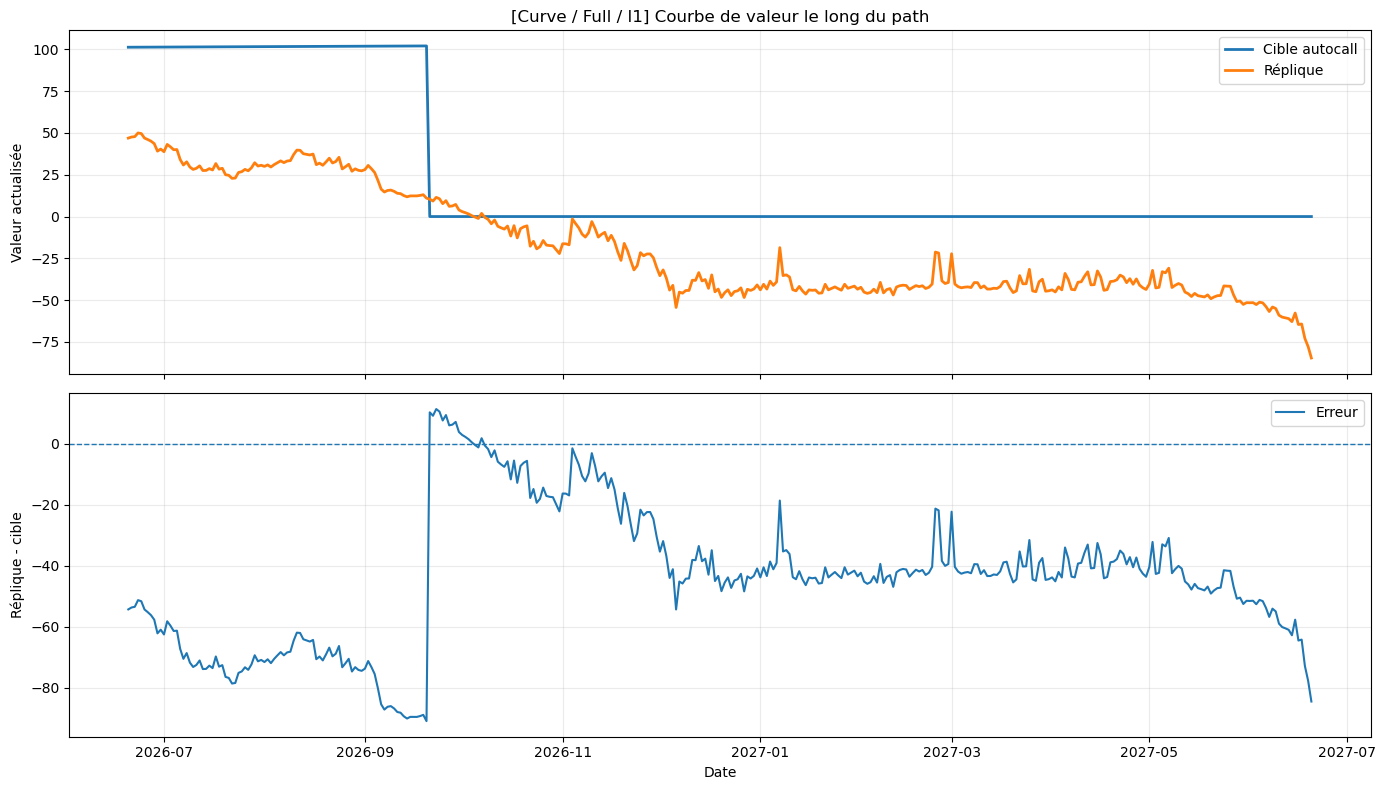

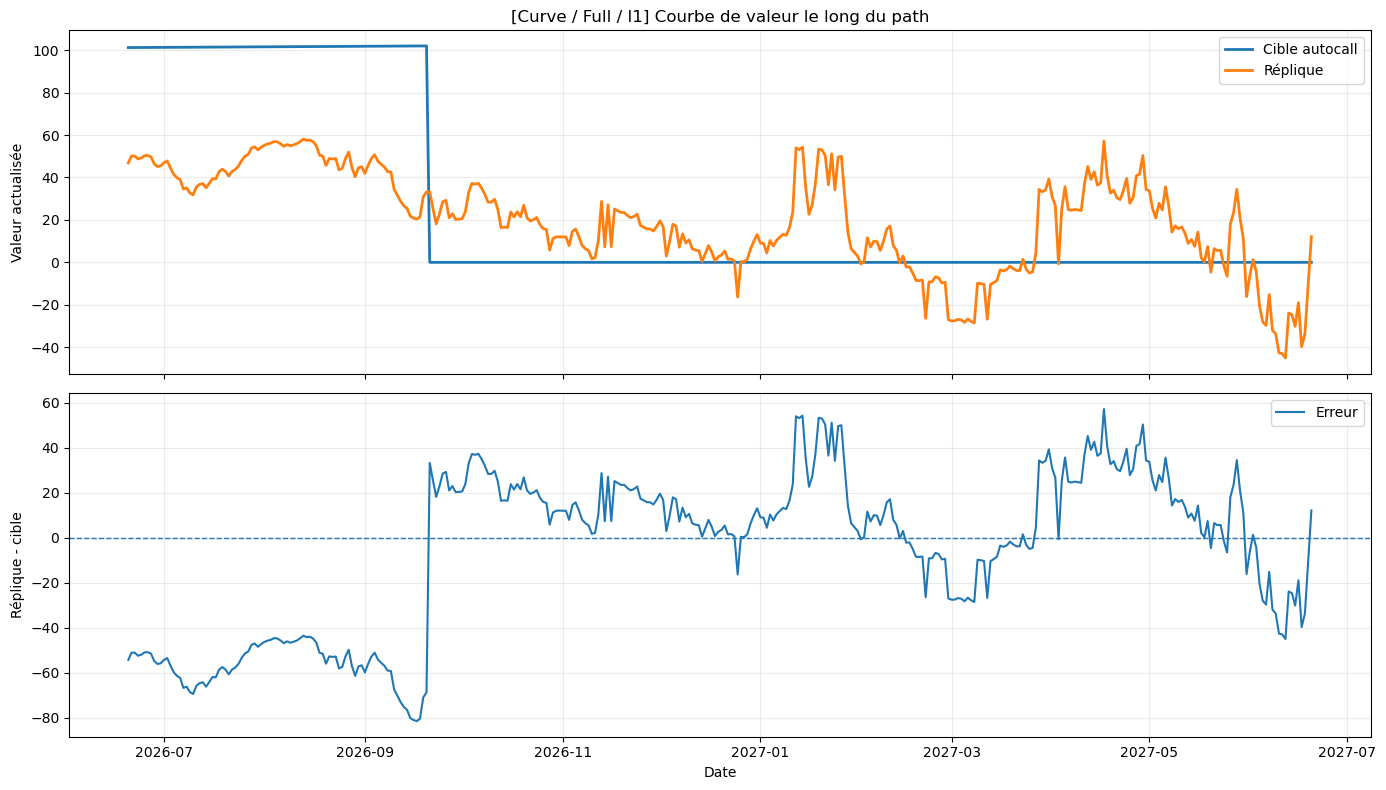

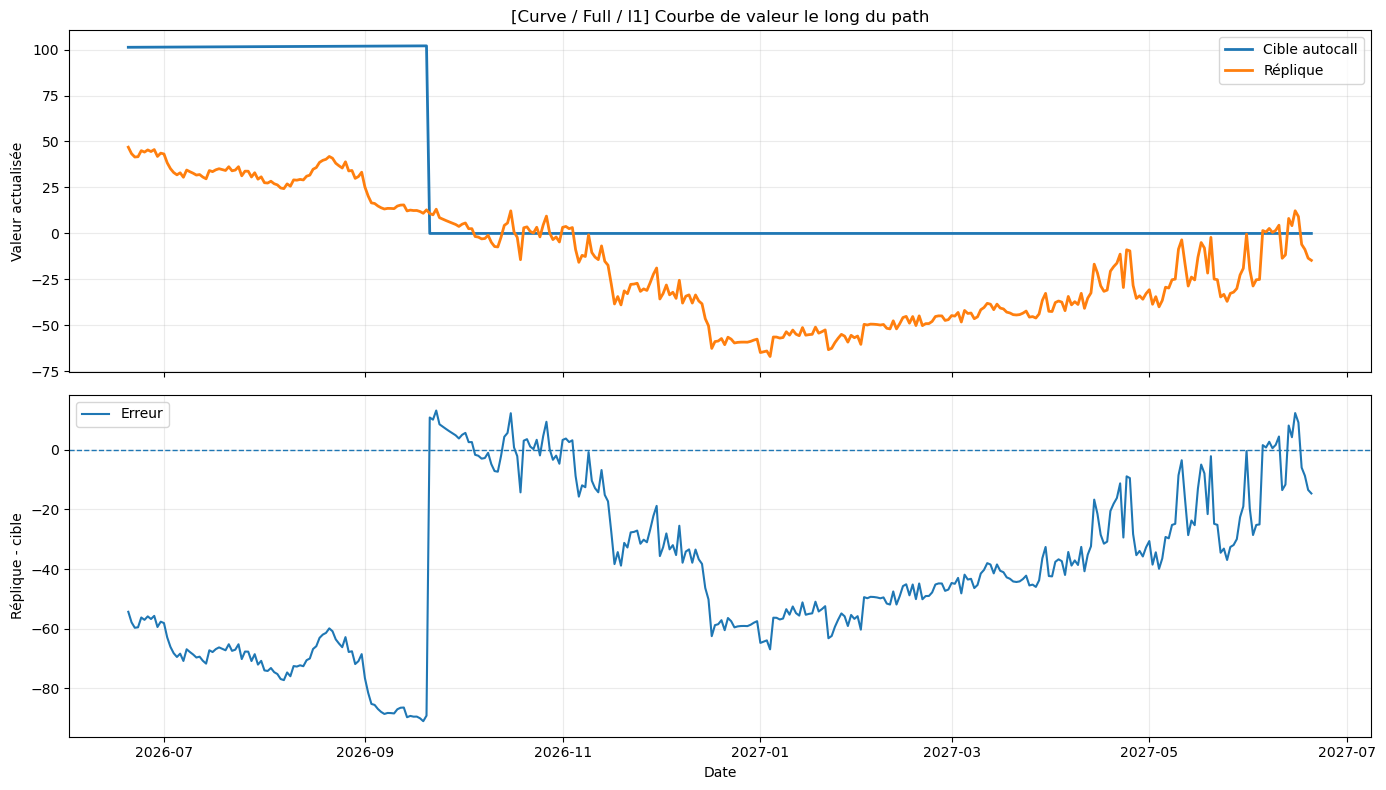

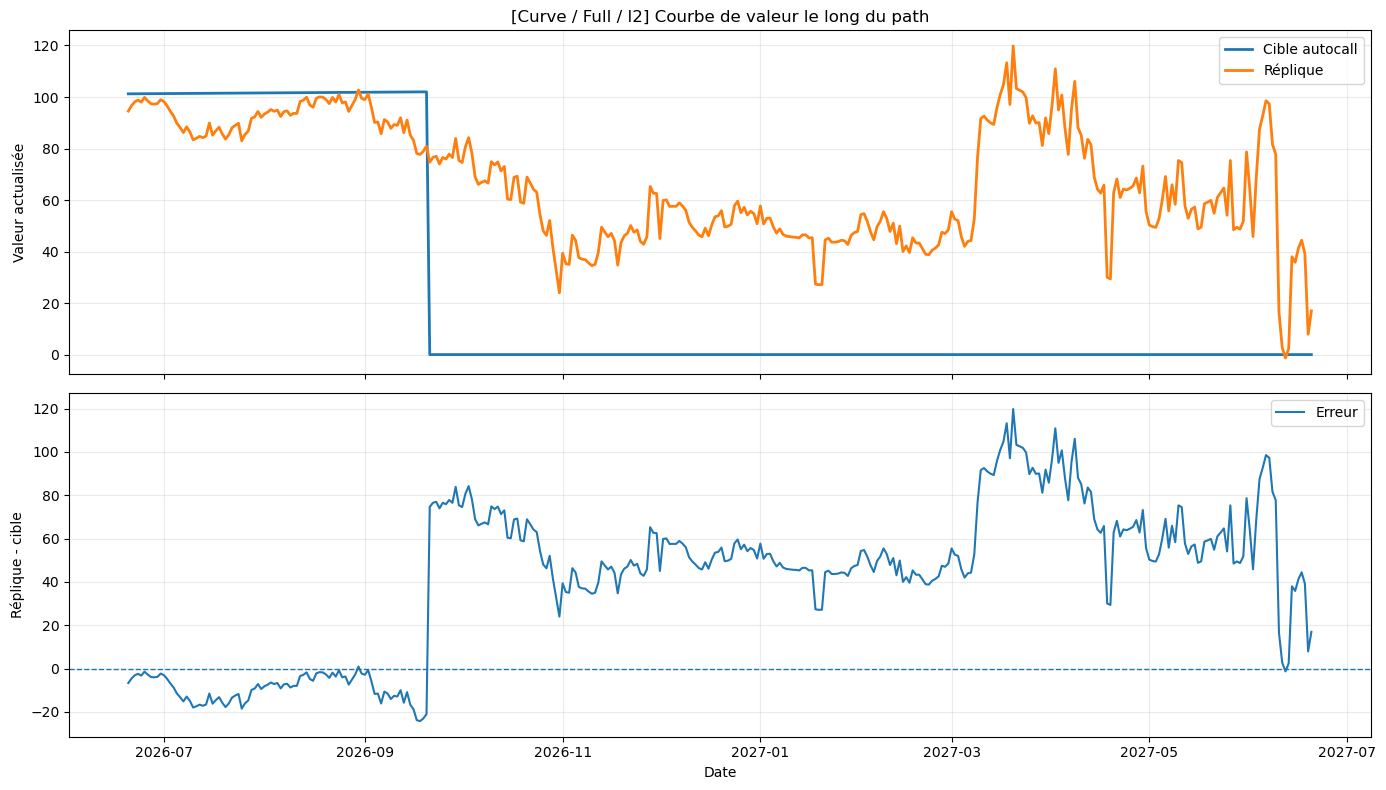

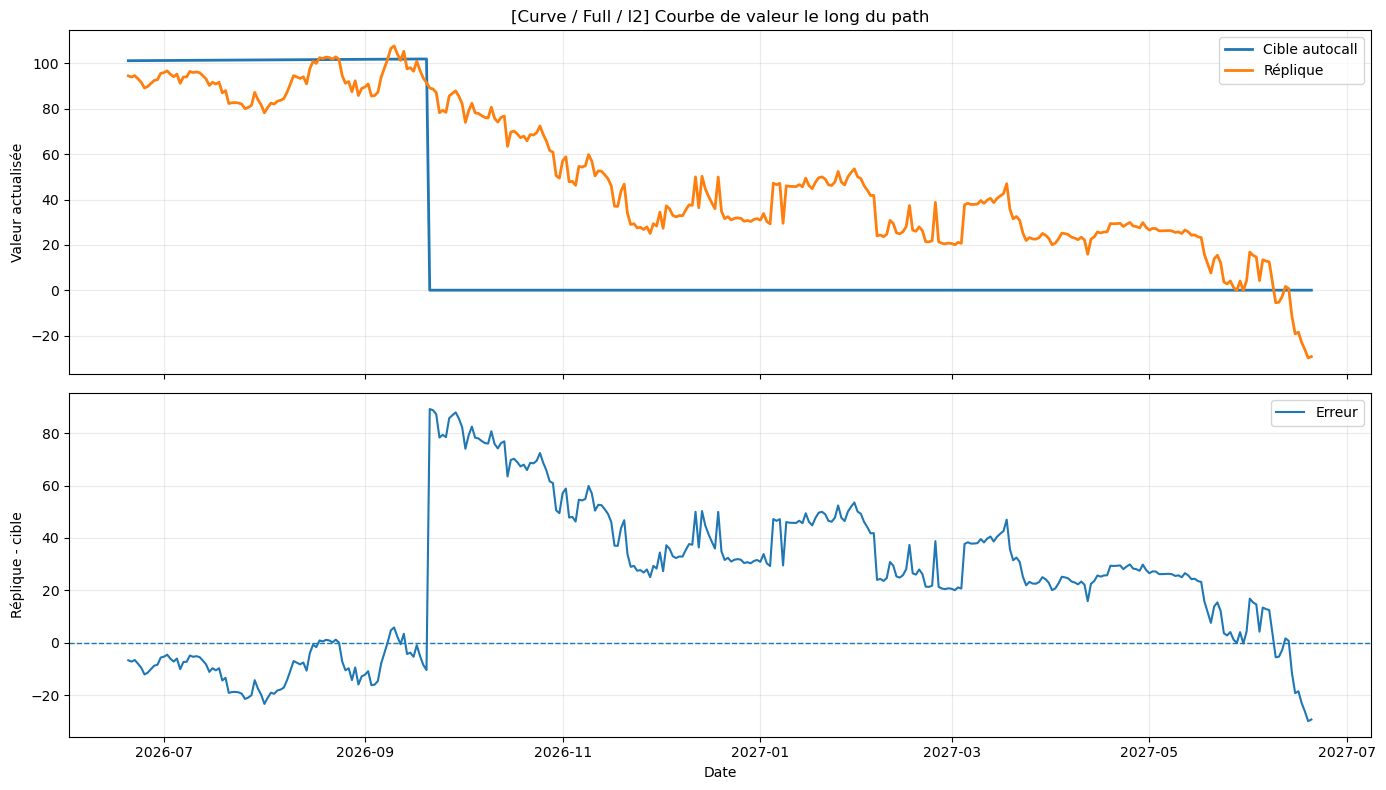

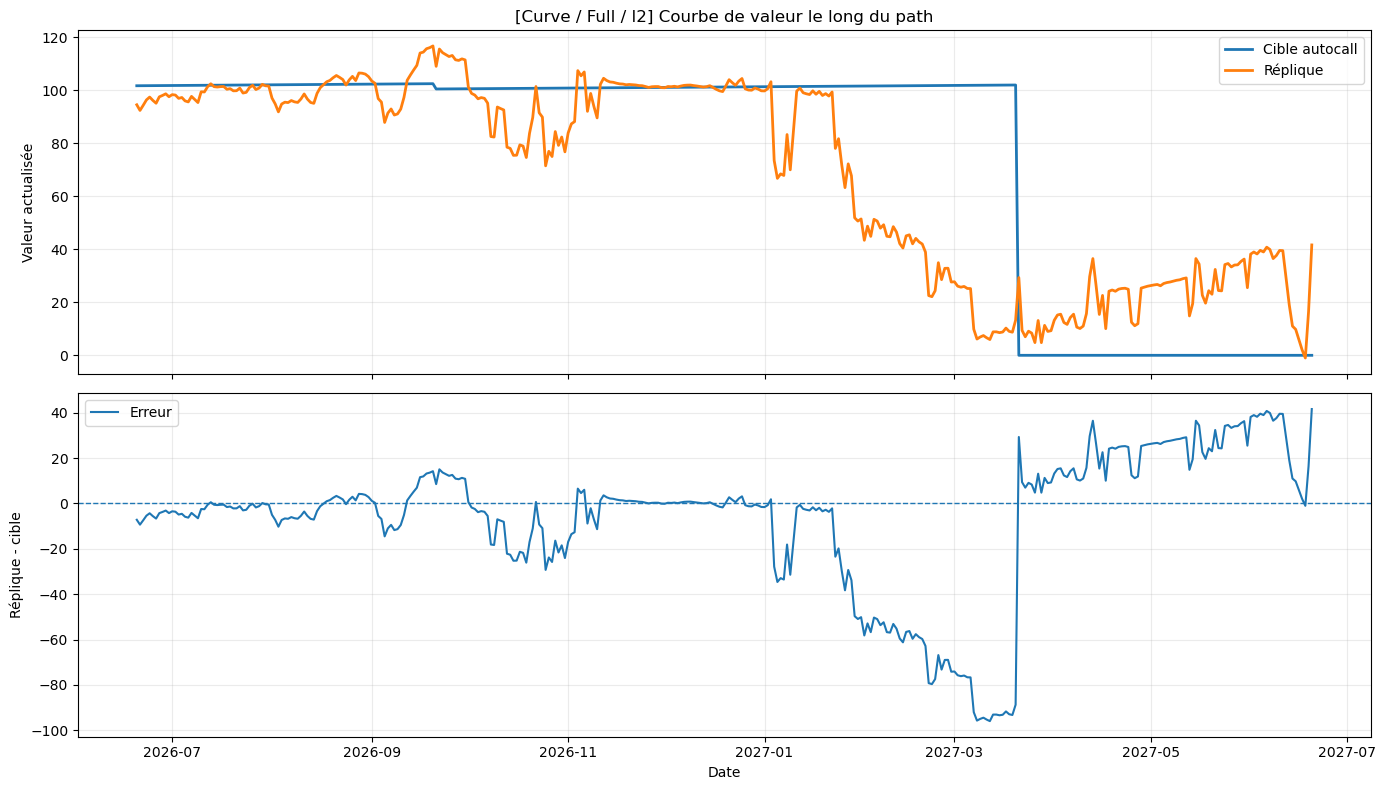

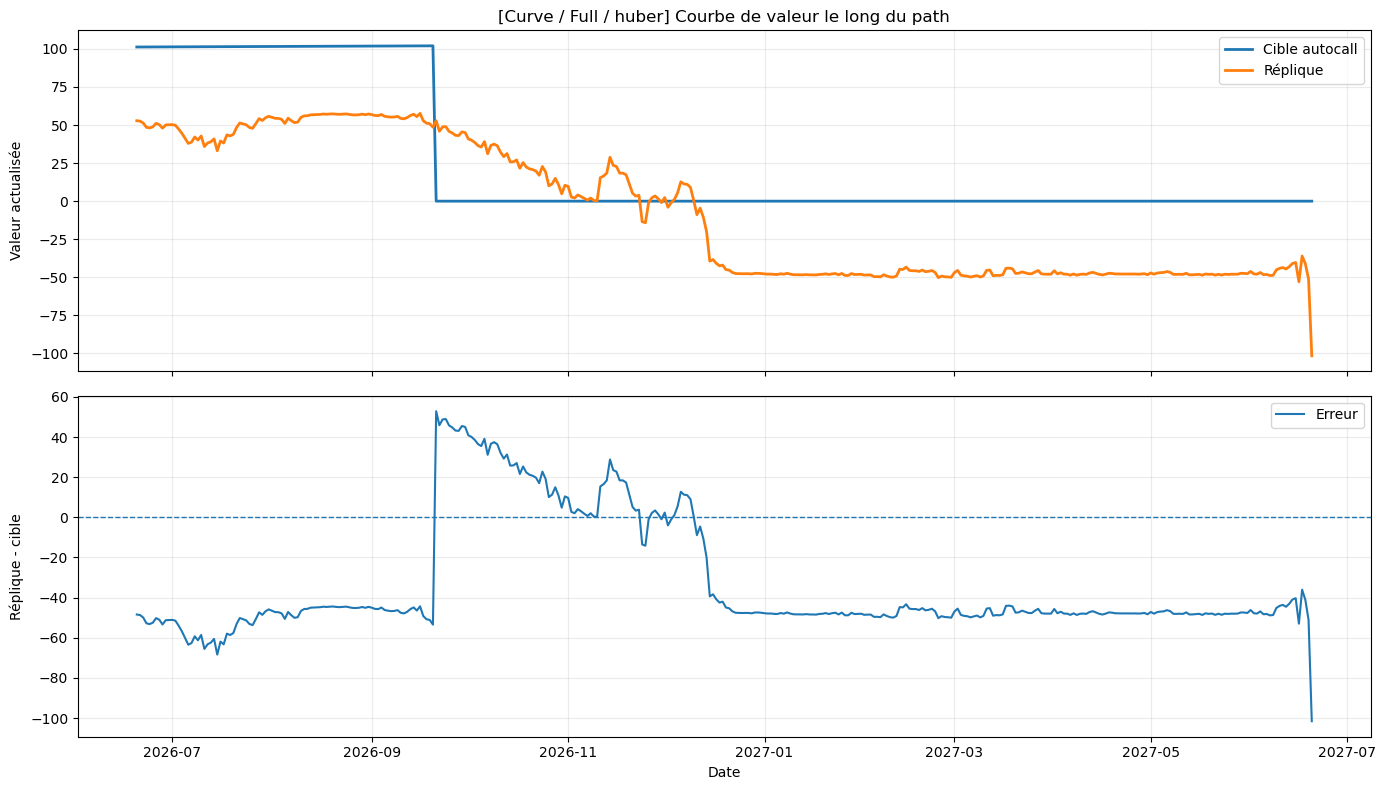

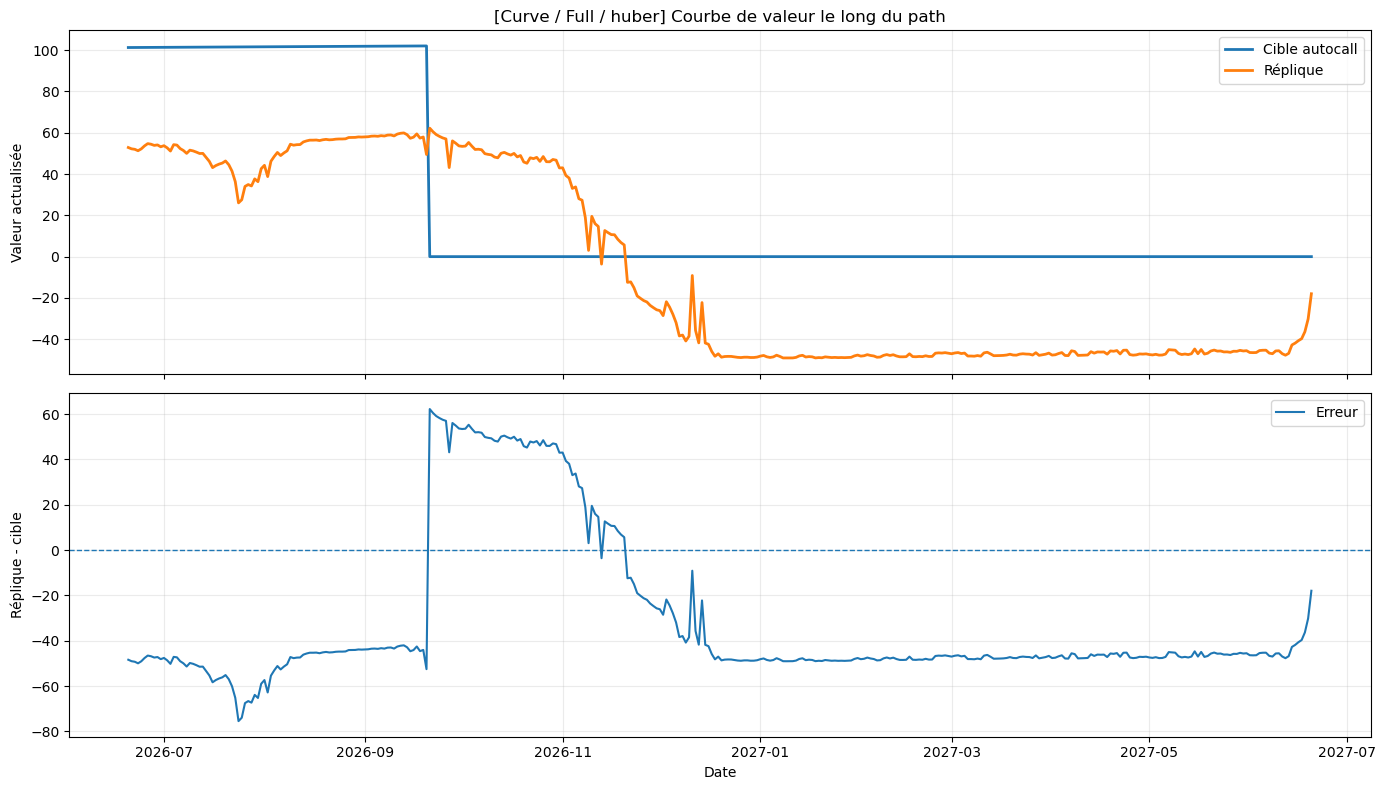

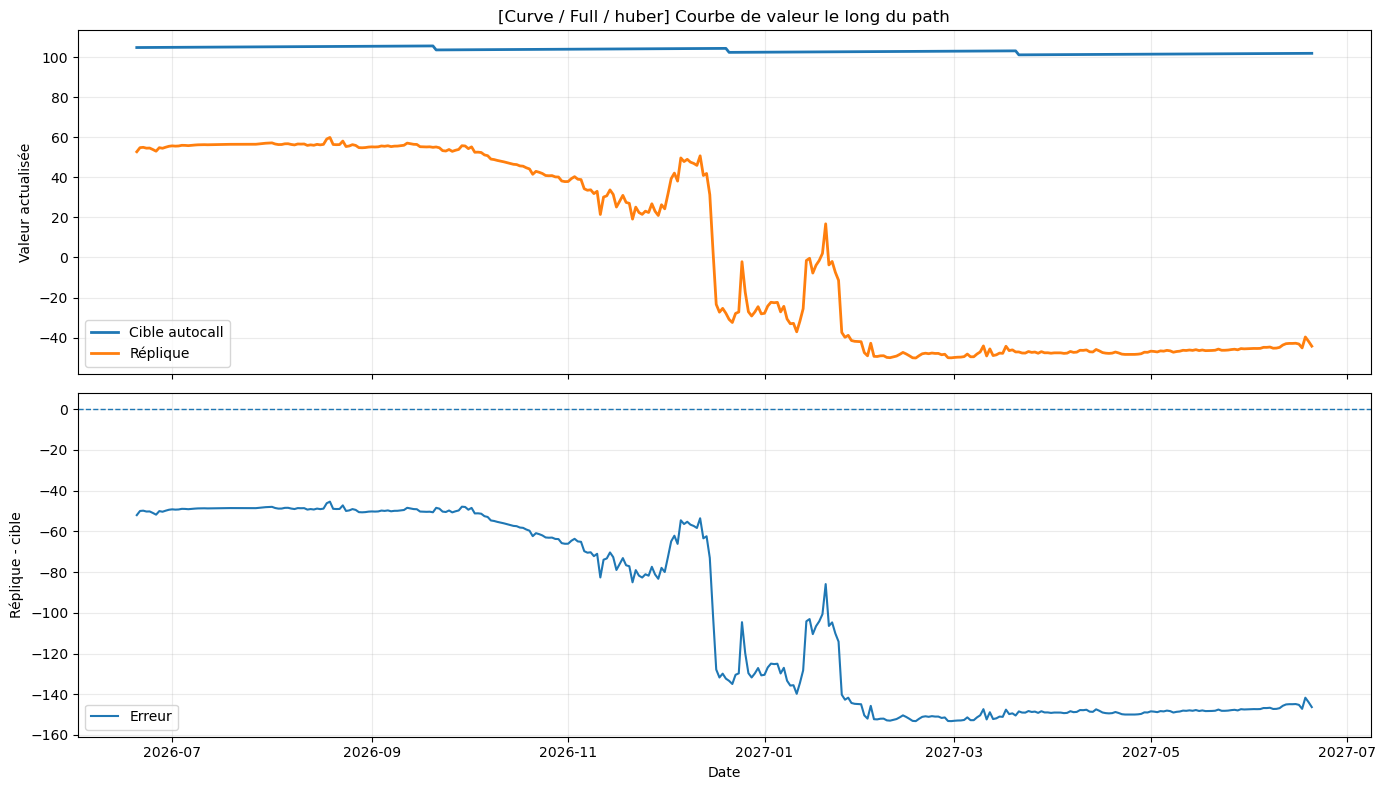

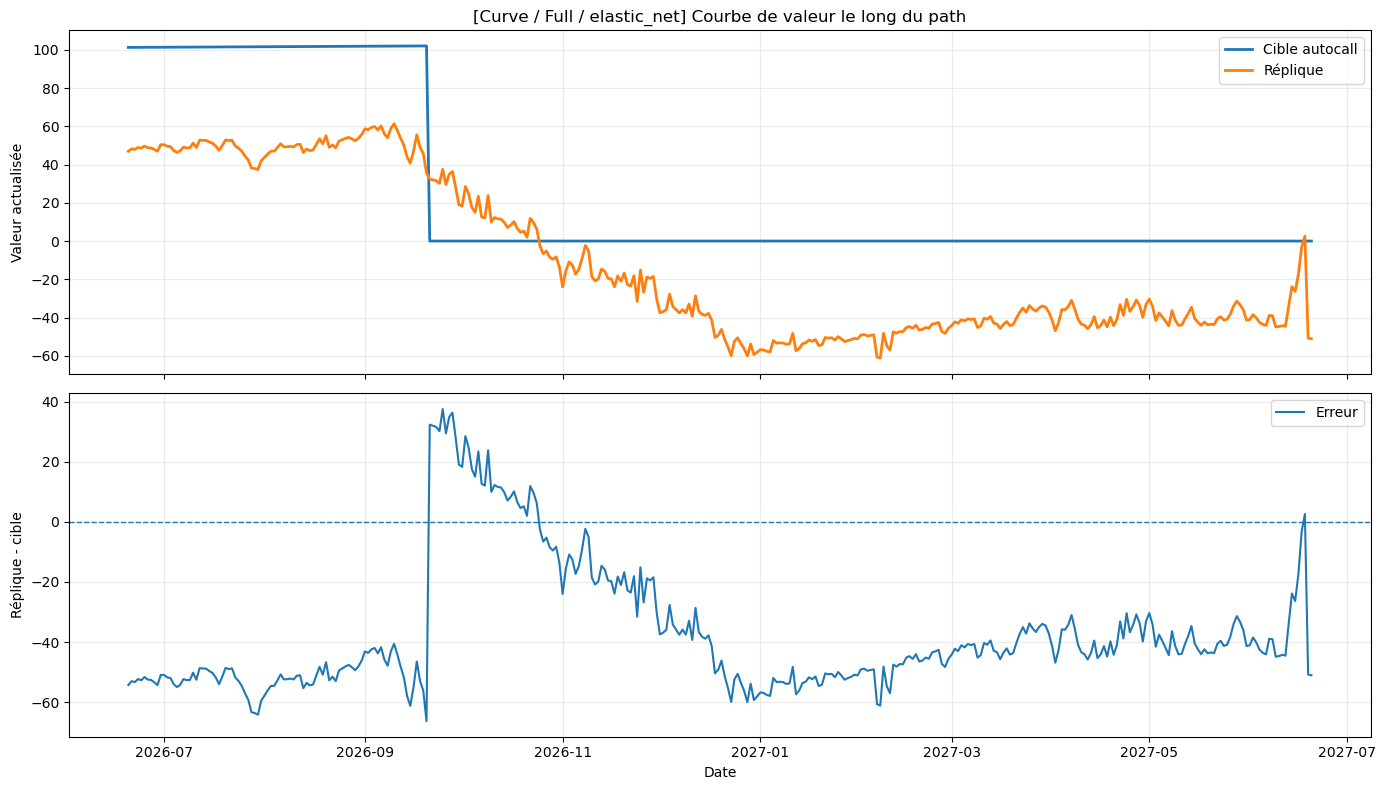

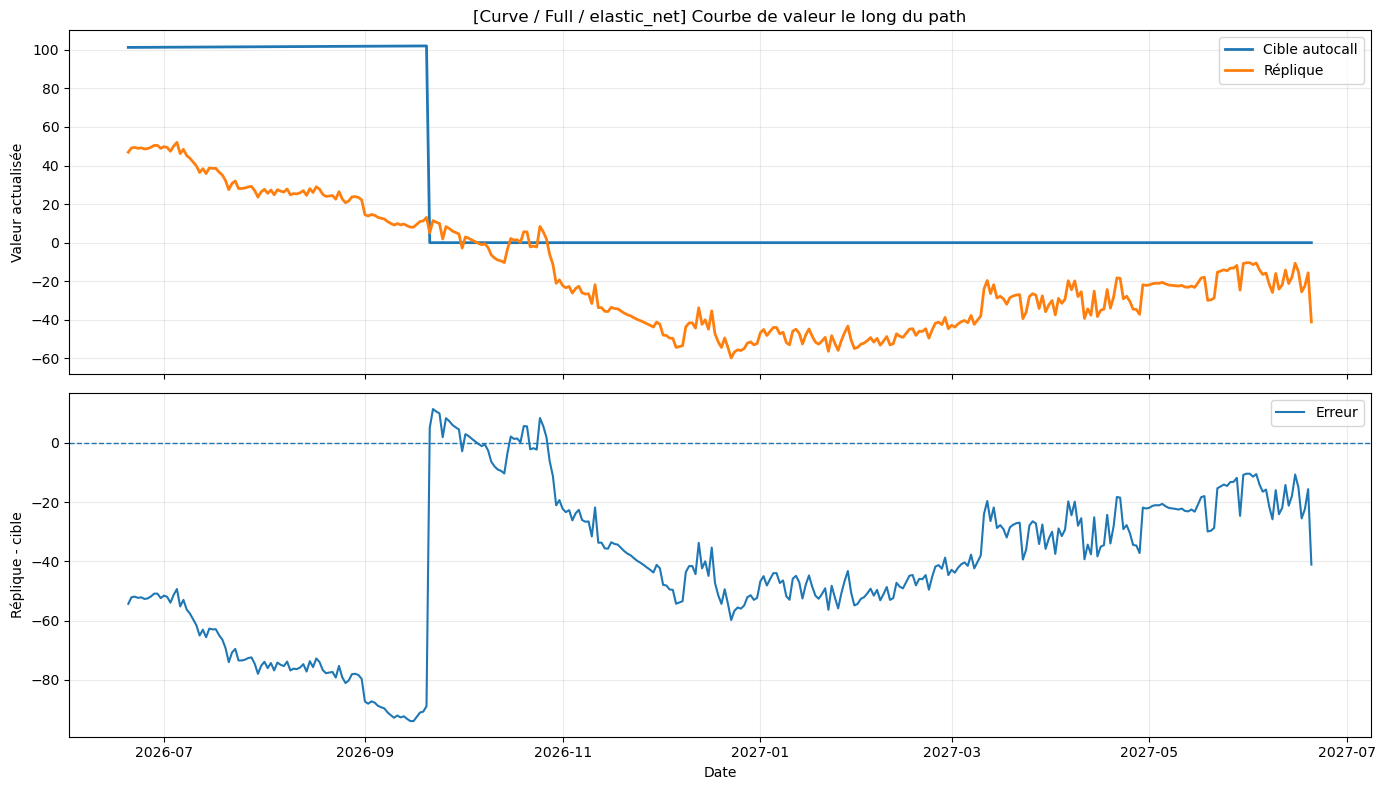

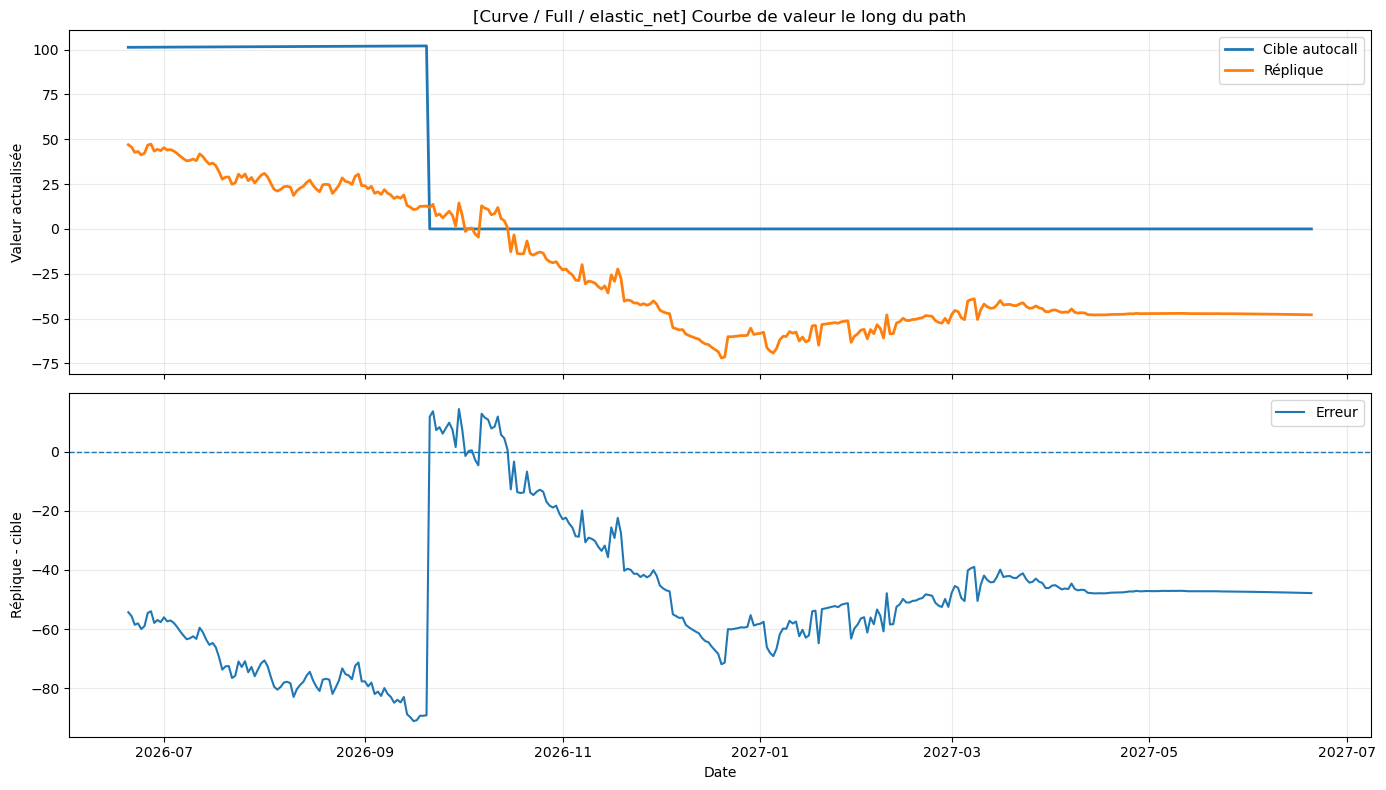

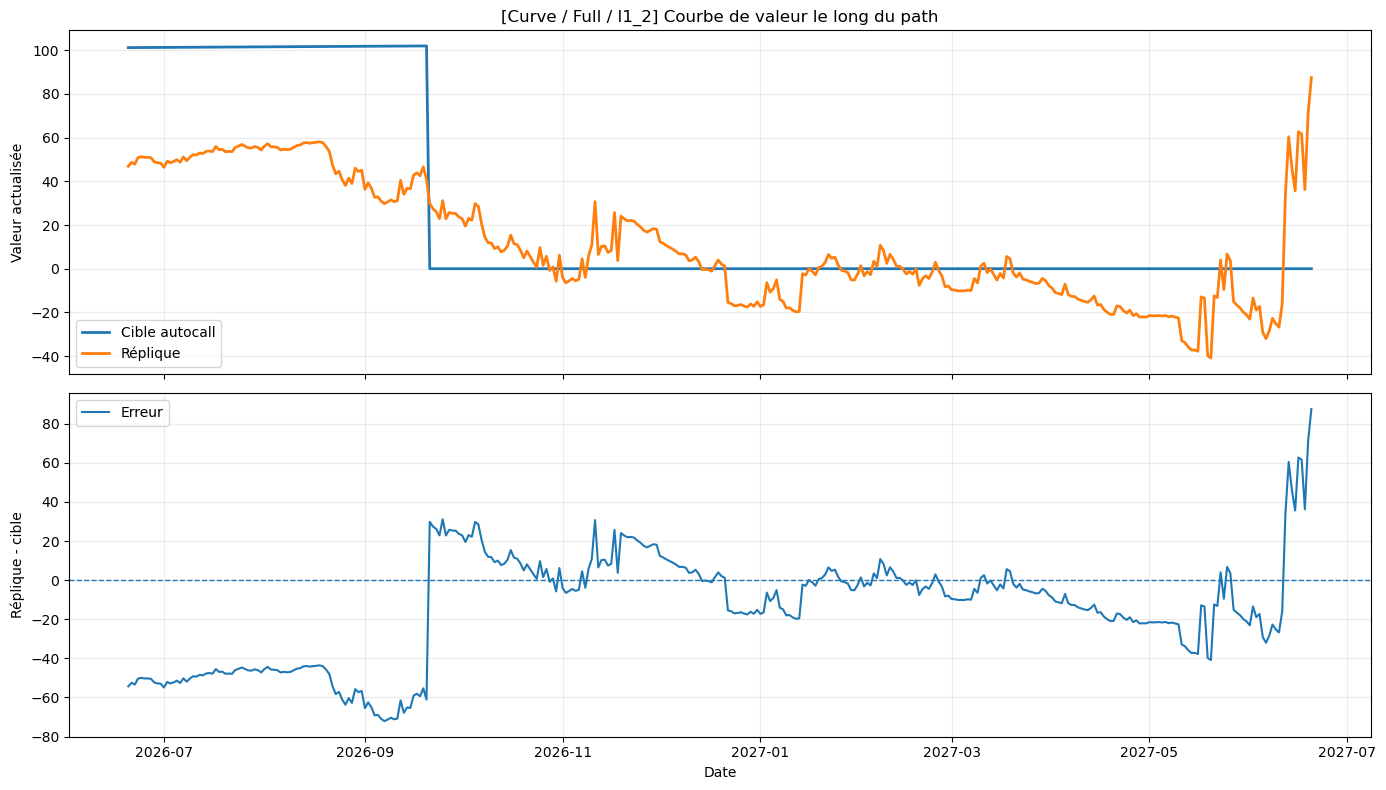

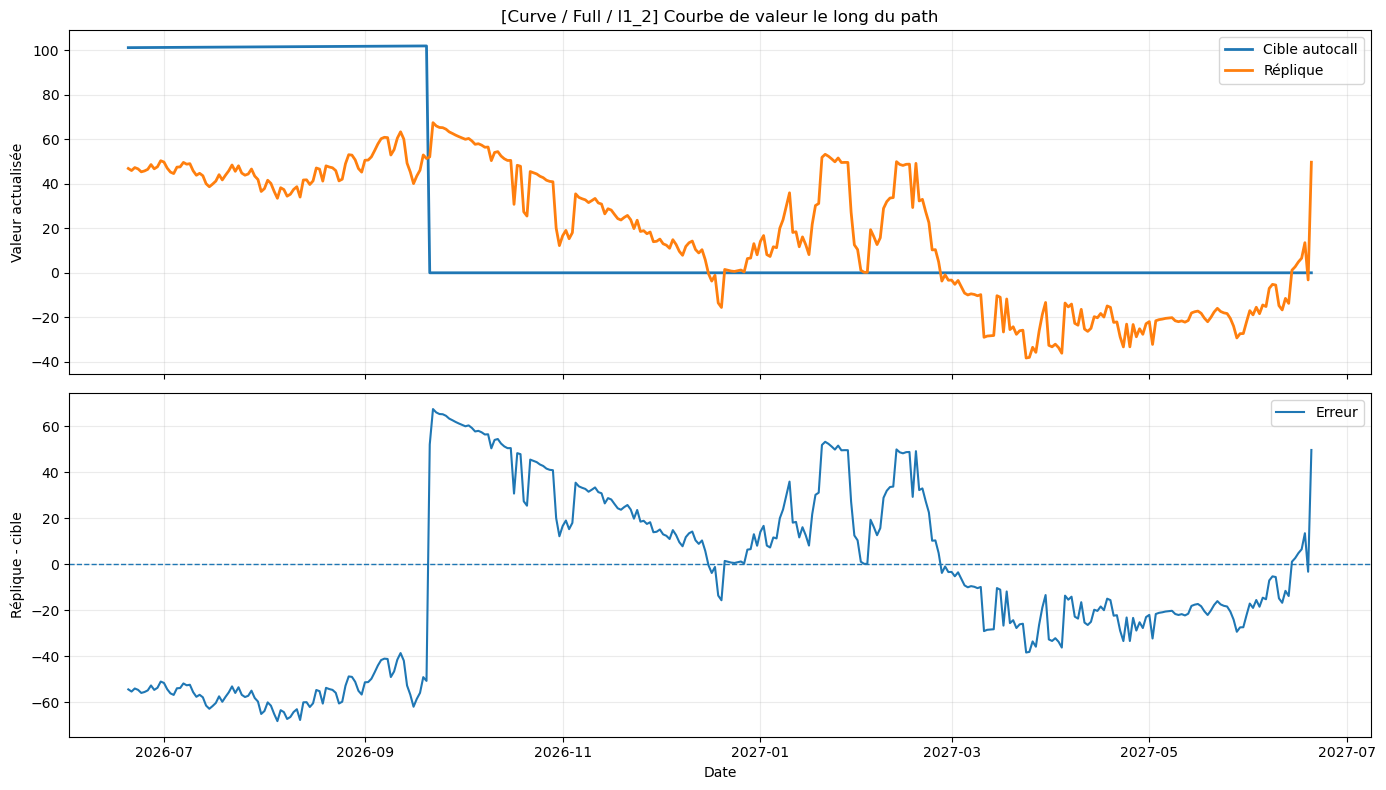

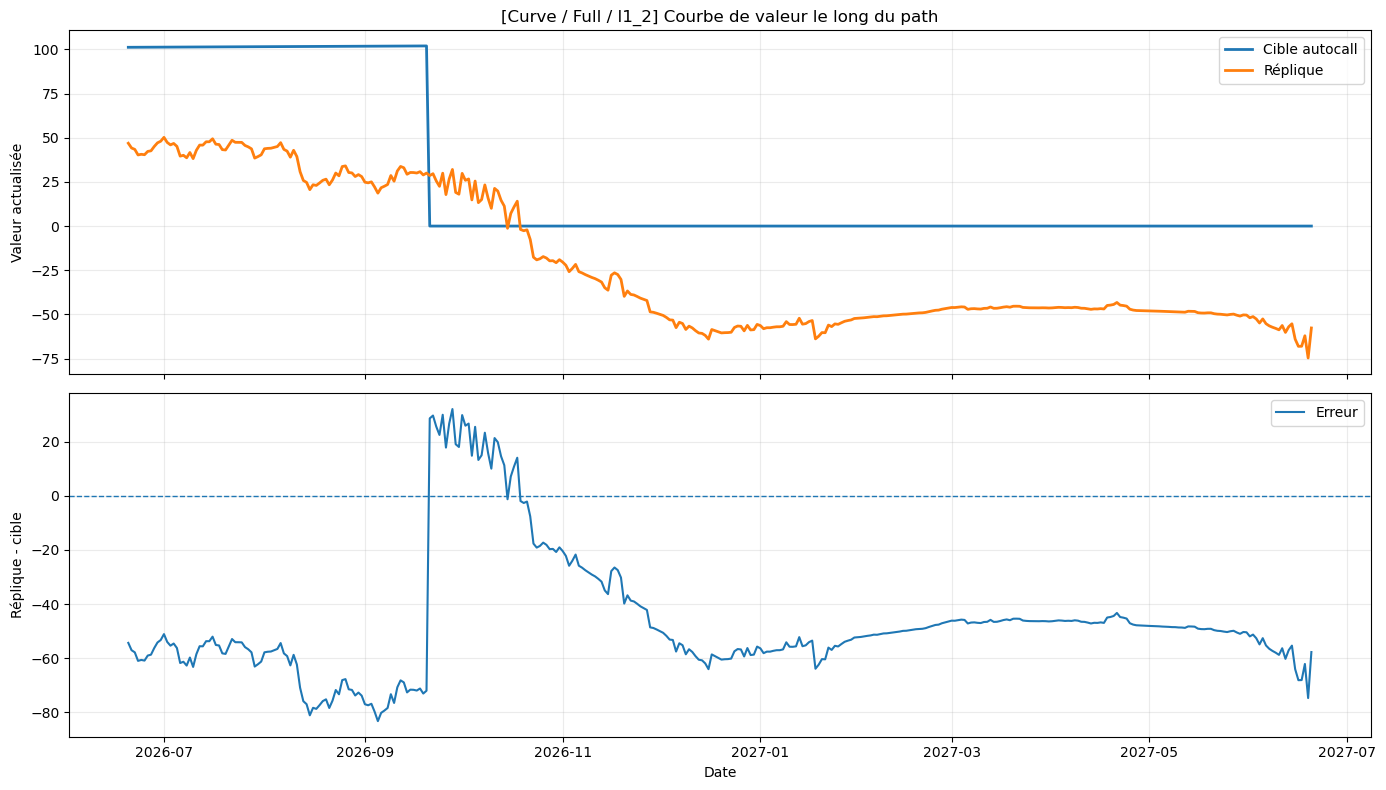

In [85]:
for penalty in ["l1","l2","huber", "elastic_net", "l1_2"] : 
    for k in range (3) : 
        res_curve = run_naive_benchmark_curve(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="full",n_paths=50,penalty=penalty,alpha=1e-6)
        test_path = simulate_gbm_path(spot0=spot0,start_date=pd.Timestamp(valuation_date),end_date=pd.Timestamp(maturity_date),rate=rate,dividend_yield=dividend_yield,vol=vol)
        target_curve = autocall_value_curve_on_path(product=prod,path=test_path,valuation_date=valuation_date,rate=rate)
        replica_curve = vanilla_portfolio_value_curve_on_path(vanillas=res_curve["vanillas"],weights=res_curve["w"],path=test_path,valuation_date=valuation_date,rate=rate,dividend_yield=dividend_yield,vol=vol)
        plot_timewise_curve_benchmark(target_curve.index,target_curve.to_numpy(),replica_curve.to_numpy(),title_prefix=f"[Curve / Full / {penalty}] ")

## 7. Grille d’entraînement

Le fit ne doit pas être fait uniquement au spot initial.  
C’est une erreur fréquente et trompeuse.

On entraîne le portefeuille sur une grille de points comprenant :

- plusieurs spots ;
- plusieurs temps résiduels ;
- plusieurs états du produit ;
- éventuellement plusieurs scénarios de volatilité ou de skew.

Cela permet de mesurer la qualité du fit non seulement localement, mais aussi en robustesse.

---

## 8. Régularisation

Le problème de fit est souvent mal conditionné.  
Il faut donc régulariser.

On peut utiliser par exemple :

$$
\min_w \|Aw - b\|^2 + \lambda \|w\|^2
$$

avec éventuellement :

- une pénalité de courbure sur les poids ;
- des contraintes de signe ;
- des contraintes de budget ;
- des contraintes de neutralité delta.

La régularisation n’est pas un détail technique : elle est essentielle pour obtenir un portefeuille interprétable et stable.

---

## 9. Critères d’évaluation

La première partie du notebook doit mesurer au moins :

- l’erreur de prix moyenne ;
- l’erreur maximale ;
- la stabilité des poids ;
- la sensibilité du fit au changement de spot ;
- la sensibilité du fit à la grille de calibration ;
- le comportement hors échantillon.

Un bon benchmark naïf n’est pas celui qui fit le mieux un seul point, mais celui qui se comporte de manière acceptable dans des conditions variées.

---

## 10. Lecture de cette baseline

Cette baseline doit être présentée comme un point de comparaison volontairement simple.

Elle ne cherche pas à exploiter toute la structure du produit.  
Elle cherche plutôt à montrer ce que permet, et surtout ce que ne permet pas, un fit direct par panier fini de vanilles.


## 11. Remarques pratiques

Les cellules suivantes construisent une petite partie “marché” du notebook. Si `yfinance` n’est pas installé, cette section s’arrête proprement sans faire planter le notebook.


## 12. Données de marché optionnelles

Cette étape est utile pour récupérer un historique de sous-jacent et une chaîne d’options de test. Elle n’est pas indispensable pour comprendre la logique de réplication, mais elle rend l’exemple plus concret.


## 13. Vérification sur un sous-jacent de marché

On prend ici un ticker de test pour illustrer la construction de l’univers de vanilles à partir de données observées.


## 14. Lecture de la chaîne d’options

L’objectif est de garder uniquement les colonnes utiles pour la suite : strike, bid, ask, volatilité implicite, volume et open interest.


## 15. Contrôle de robustesse

Cette partie sert surtout à vérifier que les données récupérées sont cohérentes avant de les utiliser dans une calibration.


## 16. Préparation du panier de vanilles

On regroupe les calls et les puts dans un seul tableau pour faciliter la construction d’un univers de réplication.


## 17. Nettoyage des colonnes

On garde volontairement peu de colonnes au départ pour éviter d’introduire du bruit inutile dans le notebook.


## 18. Dernier affichage avant calibration

Ce tableau résume l’univers de départ utilisé pour la suite des tests.


In [ ]:
ticker = "SPY"   # ou "AAPL"

if yf is None:      print("yfinance n'est pas installé dans cet environnement : la partie données de marché est ignorée.")
else:
    tk = yf.Ticker(ticker)

    # 1) Historique du sous-jacent
    spot_hist = yf.download(ticker,start="2025-01-01",end="2026-06-30",interval="1d",auto_adjust=True,progress=False)
    print("Historique spot :")
    display(spot_hist.tail())
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,gridspec_kw={"height_ratios": [3, 1]})
    ax1.plot(spot_hist.index, spot_hist["Close"], label="Close")
    ax1.plot(spot_hist.index, spot_hist["High"], label="High")
    ax1.plot(spot_hist.index, spot_hist["Low"], label="Low")
    ax1.set_title(f"Historique du sous-jacent ({ticker})")
    ax1.set_ylabel("Prix")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(spot_hist.index, spot_hist["Volume"], color="gray")
    ax2.set_ylabel("Volume")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    spot = spot_hist["Close"].dropna().iloc[-1].item()  # dernier cours de clôture disponible, utilisé comme spot de référence 
    valuation_date = pd.Timestamp(spot_hist.index[-1])

    # 2) Liste des maturités disponibles
    expiries = tk.options
    if not expiries:        print("Aucune maturité disponible pour ce ticker.")
    else:
        print("Maturities disponibles :", expiries[:])
        print("Nombre de maturités :", len(expiries))
        expiry = expiries[0]
        maturity = pd.Timestamp(expiry)

        # 3) Chaîne d'options
        chain = tk.option_chain(expiry)
        calls = chain.calls.copy()
        puts = chain.puts.copy()

        # 4) Construction d'un petit univers de vanilles
        calls["kind"] = "call"
        puts["kind"] = "put"
        vanillas_market = pd.concat([calls, puts], ignore_index=True)

        cols = [c for c in ["contractSymbol","kind","strike","lastPrice","impliedVolatility","expiration"] if c in vanillas_market.columns]
        vanillas_market = vanillas_market[cols].copy()
        
        
        # Prix Black-Scholes théorique ligne par ligne
        def _bs_price_row(row):
            sigma = row["impliedVolatility"]
            if pd.isna(sigma) or sigma <= 0:    return np.nan

            if row["kind"] == "call":   prod = EuropeanCall(name="tmp",strike=float(row["strike"]),maturity_date=maturity,notional=1.0)
            else:                       prod = EuropeanPut(name="tmp",strike=float(row["strike"]),maturity_date=maturity,notional=1.0)

            return prod.price_bs(spot, valuation_date, rate, dividend_yield, sigma)

        vanillas_market["Benchmark price BS"] = vanillas_market.apply(_bs_price_row, axis=1)
        display(vanillas_market.head(10))
